In [1]:
import torch
import pickle
import pandas as pd
import numpy as np
import sys
import glob
import math
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns

from src.utils import (
    get_valid_dir,
    set_seed,
    get_linear_predictions,
    get_knn_predictions,
    get_embs,
    is_subset,
    process_data_loader,
    print_metrics_in_latex,
    calculate_metrics,
    get_checkpoint_paths,
    mergekfold_results,
    save_normalized_conf_matrices,
    plot_pred_vs_true,
    get_class_dependent_predictions,
    generate_radar_plots,
    filter_classes,
    get_mlp_predictions,
)

from src.models_multimodal import (
    load_model,
)

from sklearn.metrics import roc_curve, auc

from src.dataloader import (
    load_data,
    NoisyDataLoader,
)

ZTF18aahhzqn 58225.156007433274 18 0.045404674280556695


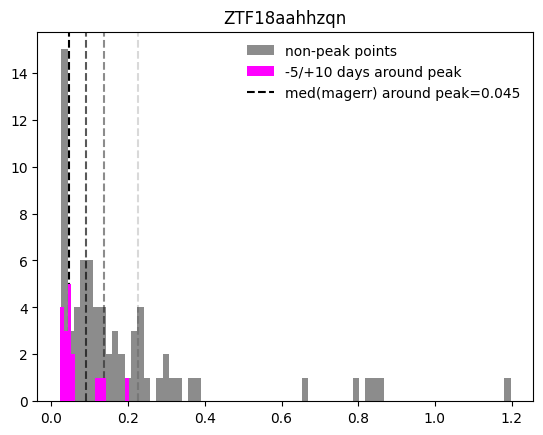

ZTF18aahuujv 58673.730375626124 28 0.05300361082408215


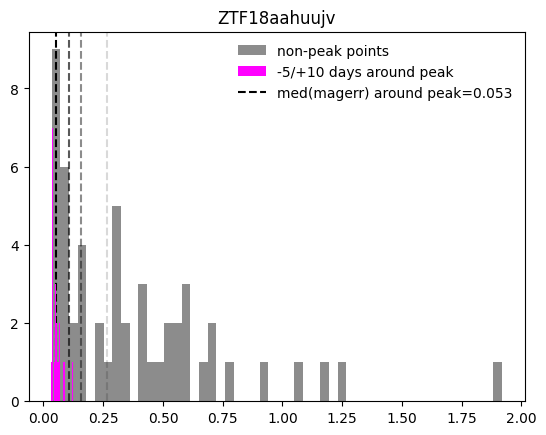

ZTF18aakuewf 58231.12935593881 56 0.03219270089479555


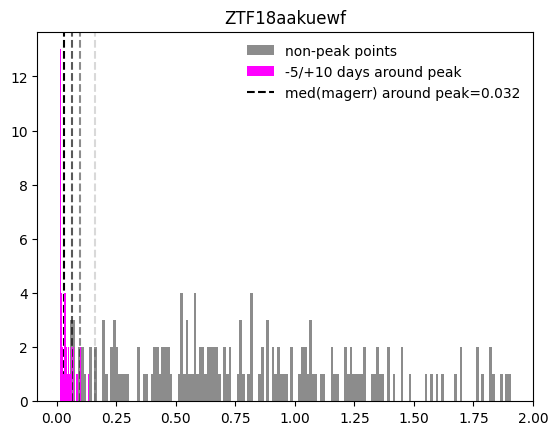

ZTF18abojpnr 58370.05127571946 76 0.0377379064157949


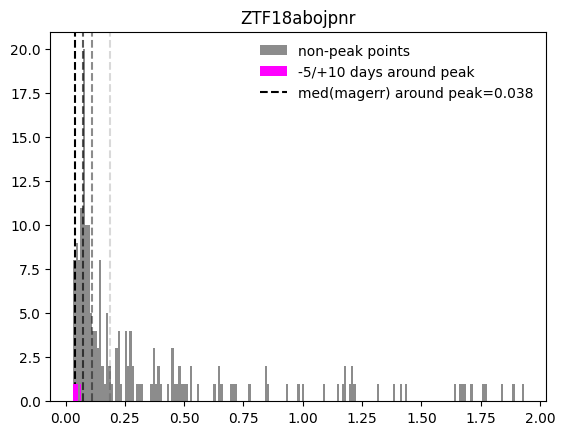

ZTF18absliyc 58371.68541410136 37 0.0366603384251375


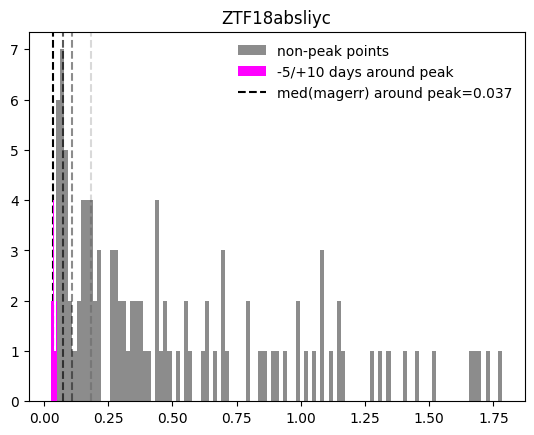

ZTF18abwkrbl 58380.321465977366 33 0.0071757503390309


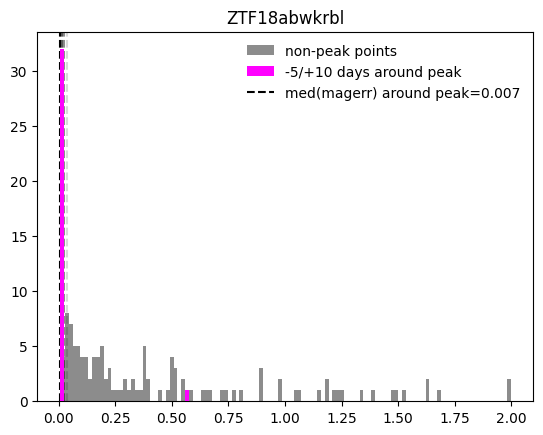

ZTF18acisruf 58440.72346540898 4 0.17662305974485745


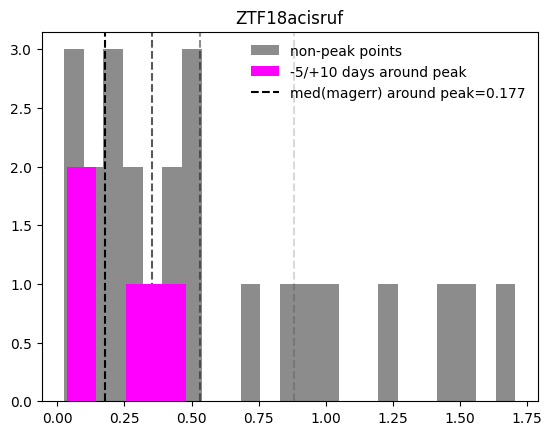

ZTF18acnmifq 58456.102895245866 29 0.0763846931195247


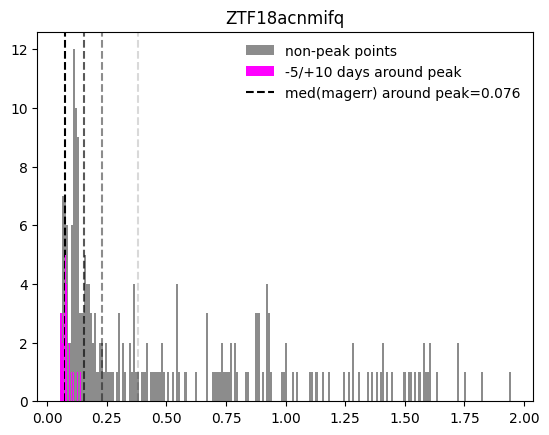

ZTF18acqphpd 58450.63804132751 7 0.0300454106223837


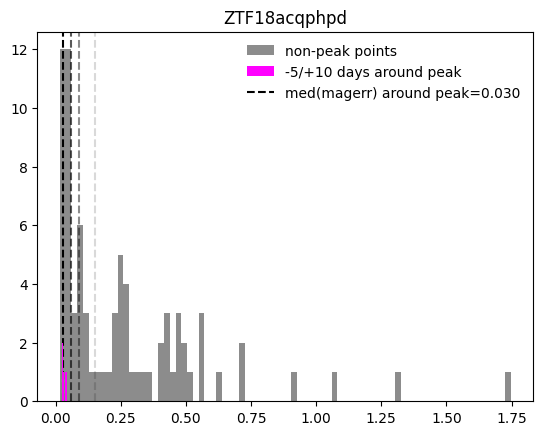

ZTF18acrcyqw 58460.141490734735 9 0.025540586427883


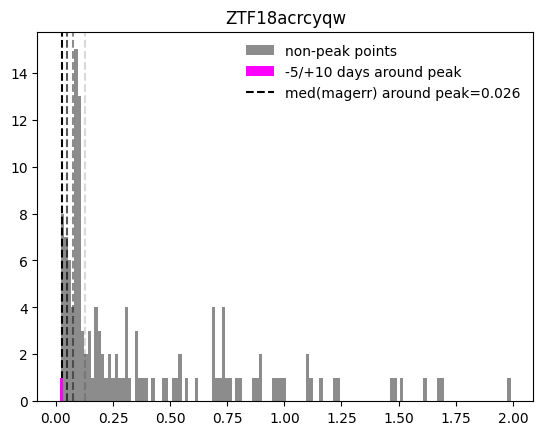

ZTF18aczqzrj 58483.665183099256 11 0.0257070246885501


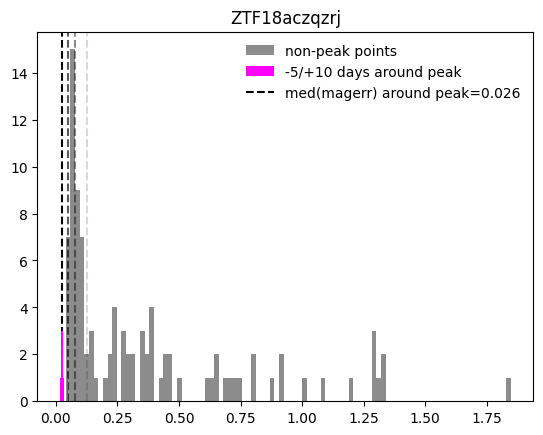

ZTF19aadwtoe 58509.80134561199 143 0.0285902470432438


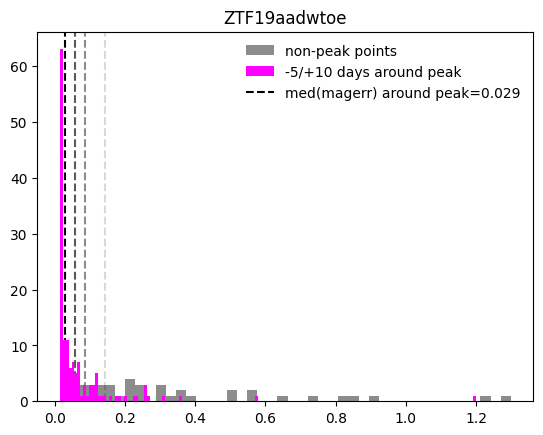

ZTF19aalouag 58585.24155910923 102 0.03810901792333585


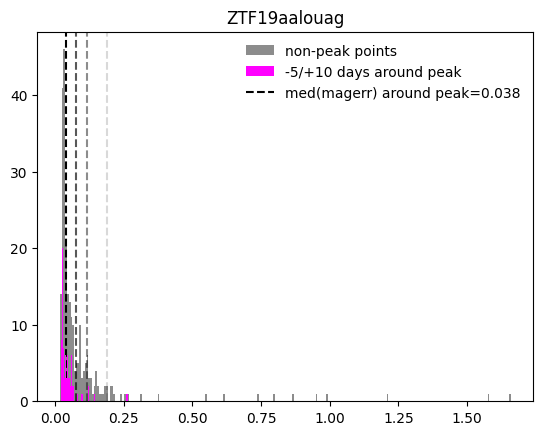

ZTF19aamsetj 58596.01843439215 9 0.0180020832028083


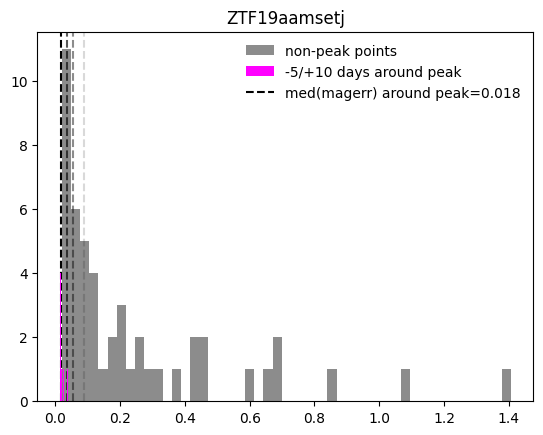

ZTF19aanijpu 58600.6092519056 13 0.0174403264902134


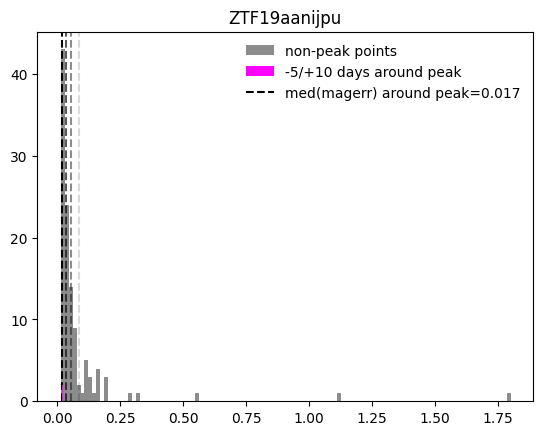

ZTF19aapceyj 58592.55357488526 18 0.06928498593902024


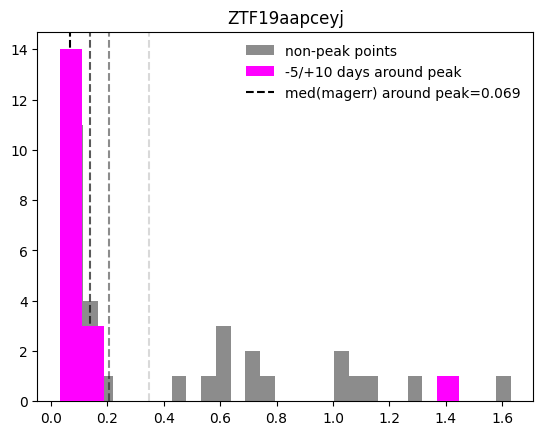

ZTF19aapfmki 58586.66662784133 26 0.033675791070007


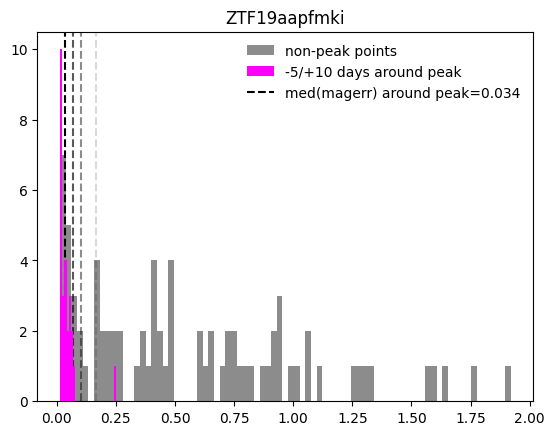

ZTF19aarfyvc 58615.21993439333 26 0.03855260944845125


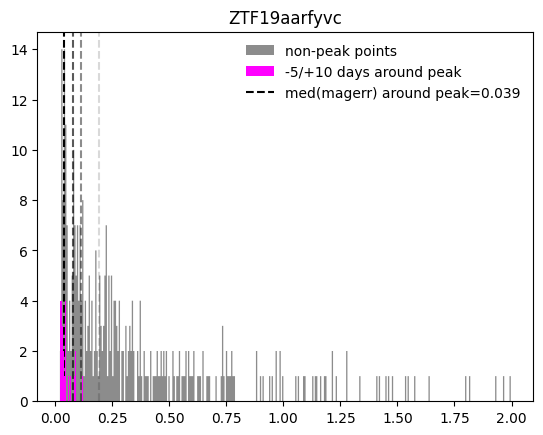

ZTF19aarnqys 58598.351233781366 7 0.0619669848924927


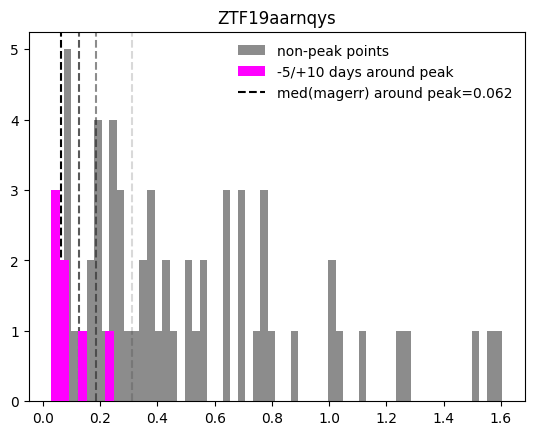

ZTF19aatheus 58617.161157943774 26 0.01121218548861445


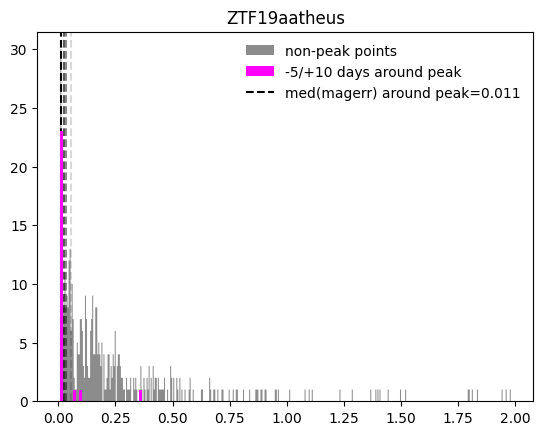

In [87]:
%matplotlib inline
# read in unique lc's (ignore repeats)
# plot hist of magerr (color code by around-peak & not-peak?)
    # print median error around peak
    #NOTE: sigma_mag is magerr

info_file = pd.read_csv('data/test/all/ZTFBTS_TransientTable.csv')
ztf_names = info_file.loc[info_file['synthetic']==False,'ZTFID'].to_list() #selecting only real ztf LCs

for sn in ztf_names[0:20]:
    lc = pd.read_csv(f'data/test/all/light-curves/{sn}_0.csv') #only taking the first copy

    peak_mjd = info_file.loc[info_file['ZTFID']==sn, 'peakt'].iloc[0]
    
    #collecting points -5<= peak mjd [days]<= +10
    peak_pnts = lc.loc[(peak_mjd-5<=lc['time'])&(lc['time']<=peak_mjd+10)]
    median_magerr = peak_pnts['magerr'].median()

    print(sn, peak_mjd, len(peak_pnts), median_magerr)
    
    plt.figure()
    plt.hist(lc.loc[~((peak_mjd-5<=lc['time'])&(lc['time']<=peak_mjd+10)),'magerr'], 
             color='gray', alpha=0.9, histtype='stepfilled', bins=len(lc.loc[~((peak_mjd-5<=lc['time'])&(lc['time']<=peak_mjd+10)),'magerr']),zorder=0,
             label='non-peak points')
    plt.hist(lc.loc[(peak_mjd-5<=lc['time'])&(lc['time']<=peak_mjd+10),'magerr'], 
             color='magenta', bins=len((lc.loc[(peak_mjd-5<=lc['time'])&(lc['time']<=peak_mjd+10),'magerr'])), label='-5/+10 days around peak', zorder=10)
    plt.axvline(median_magerr, 
                linestyle='--', color='black', zorder=0, label=f'med(magerr) around peak={median_magerr:.3f}')
    plt.axvline(2*median_magerr, linestyle='--', color='black', zorder=1, alpha=0.65)
    plt.axvline(3*median_magerr, linestyle='--', color='black', zorder=1, alpha=0.45)
    plt.axvline(5*median_magerr, linestyle='--', color='black', zorder=1, alpha=0.15)
    plt.title(sn)
    plt.legend(frameon=False)
    # plt.savefig(f'figures/ztf_lc_err_dists/{sn}_err_dist.png')
    # plt.close()
    plt.show()

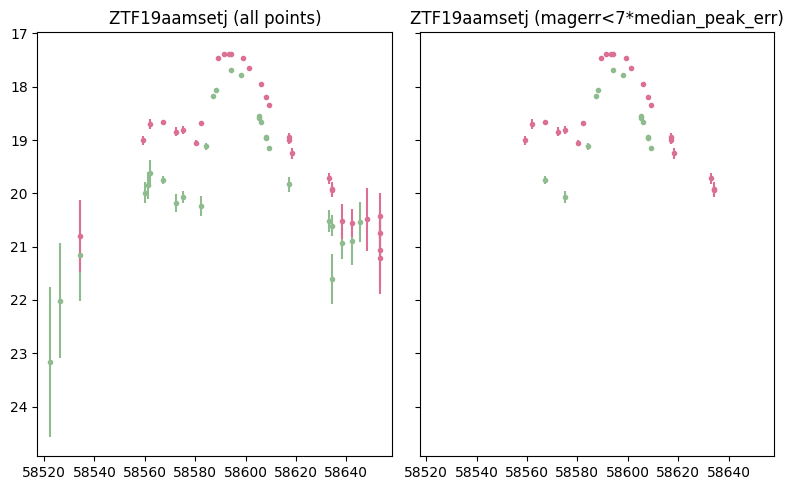

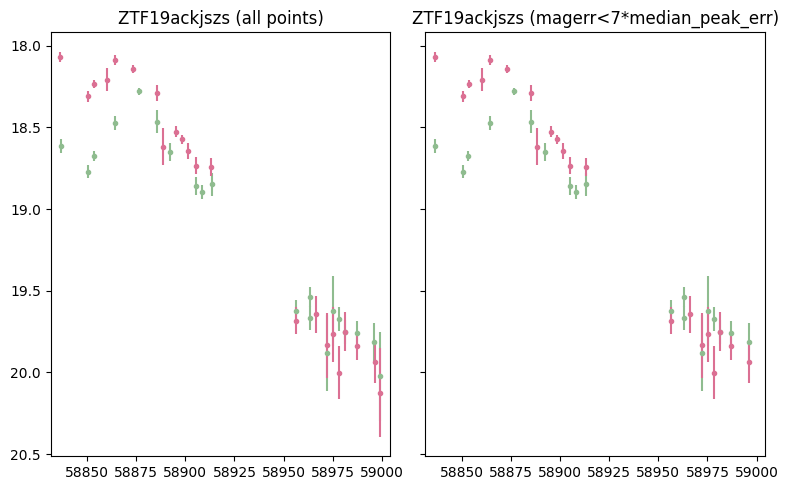

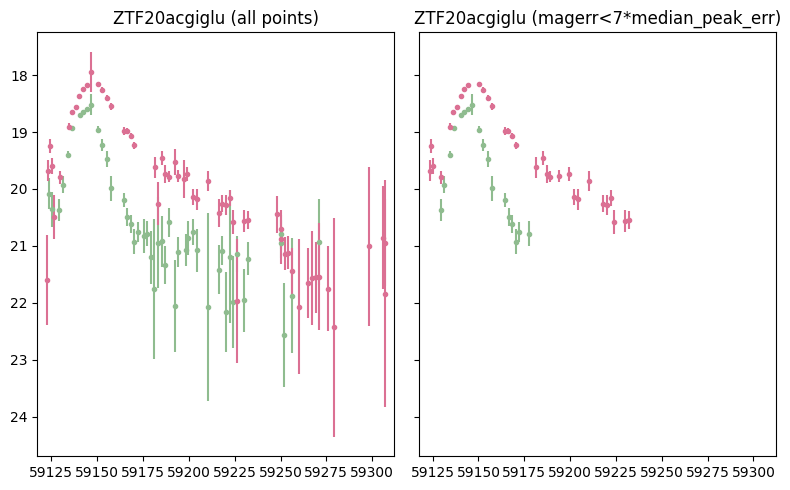

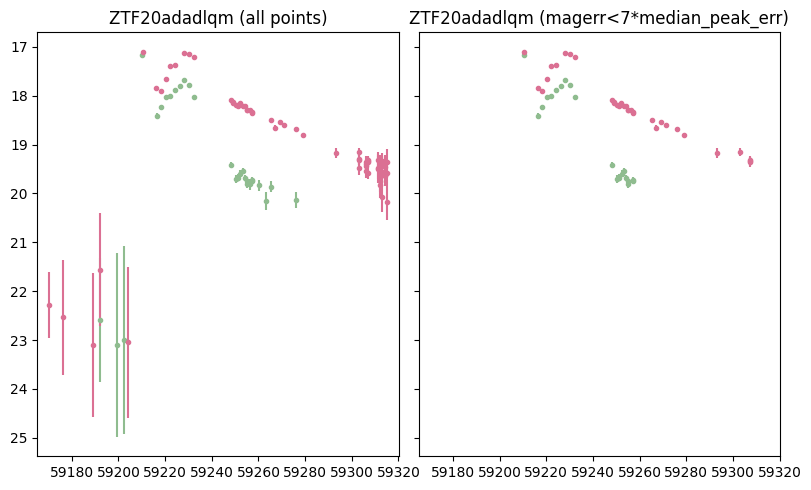

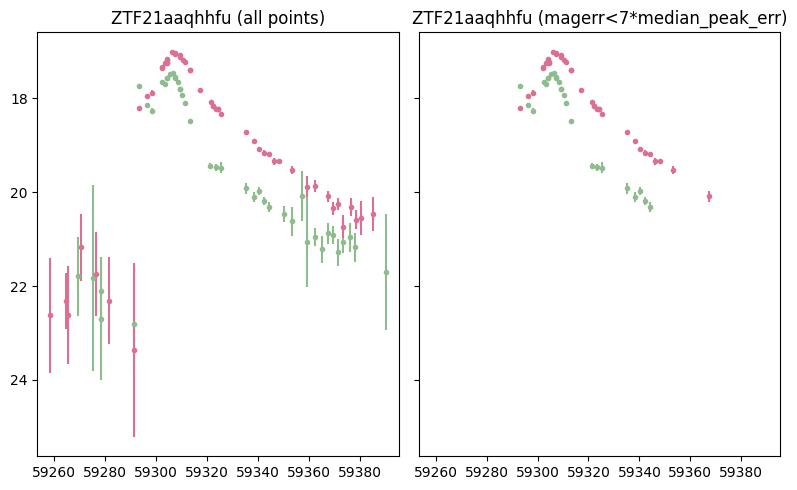

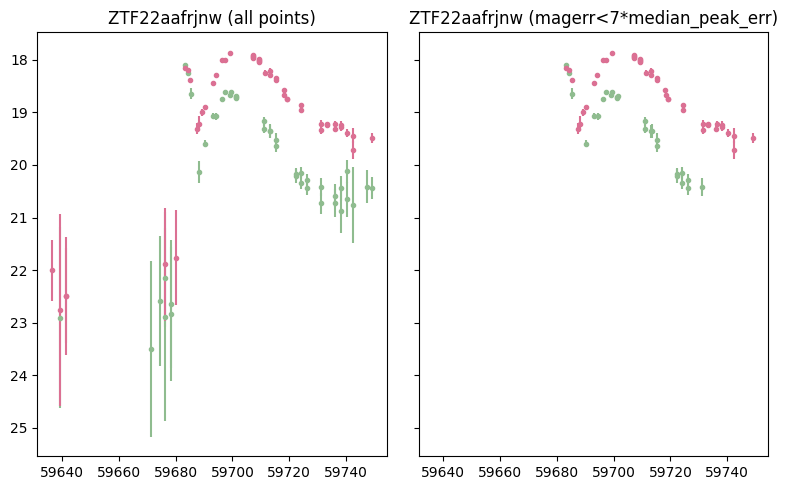

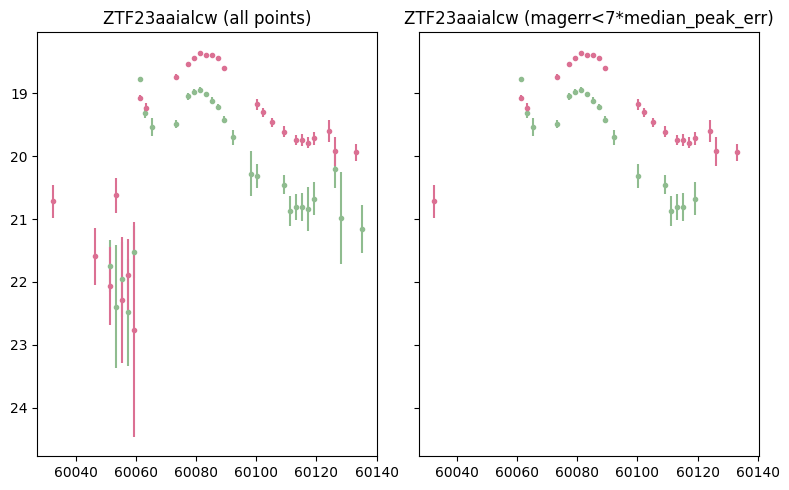

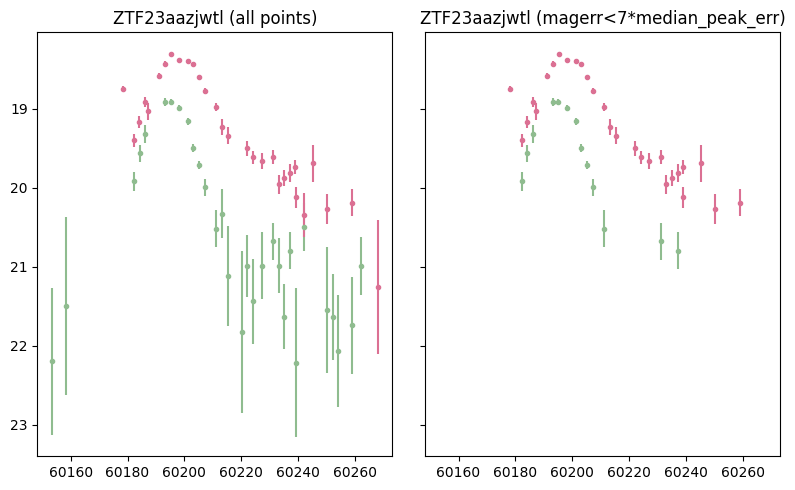

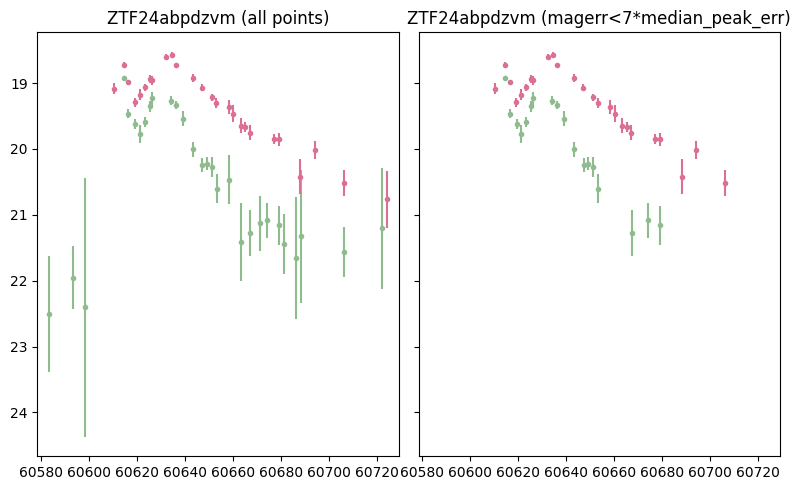

In [110]:
dp_names = info_file.loc[(info_file['synthetic']==False)&(info_file['double-peaked']==True),'ZTFID'].to_list() #selecting only real ztf LCs

for sn in dp_names:
    lc = pd.read_csv(f'data/test/all/light-curves/{sn}_0.csv') #only taking the first copy

    peak_mjd = info_file.loc[info_file['ZTFID']==sn, 'peakt'].iloc[0]
    
    #collecting points -5<= peak mjd [days]<= +10
    peak_pnts = lc.loc[(peak_mjd-5<=lc['time'])&(lc['time']<=peak_mjd+10)]
    median_magerr = peak_pnts['magerr'].median()

    err_factor = 7
    good_err = (lc['magerr']<err_factor*median_magerr)

    # print(sn, peak_mjd, len(peak_pnts), median_magerr)

    # # re-make light curves but only include points w/  0<magerr<0.25
    # plt.figure()
    # # good_err = (lc['magerr']<0.25)
    
    
    # plt.errorbar(lc.loc[(lc['band']=='g')&good_err,'time'],lc.loc[(lc['band']=='g')&good_err,'mag'],lc.loc[(lc['band']=='g')&good_err,'magerr'],
    #              marker='.',ls='',color='darkseagreen')
    # plt.errorbar(lc.loc[(lc['band']=='R')&good_err,'time'],lc.loc[(lc['band']=='R')&good_err,'mag'],lc.loc[(lc['band']=='R')&good_err,'magerr'],
    #              marker='.',ls='',color='palevioletred')
    # plt.gca().invert_yaxis()
    # plt.title(sn)

    fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

    # Left panel: all points
    ax = axes[0]
    ax.errorbar(lc.loc[lc['band']=='g','time'], lc.loc[lc['band']=='g','mag'], lc.loc[lc['band']=='g','magerr'],
                marker='.', ls='', color='darkseagreen')
    ax.errorbar(lc.loc[lc['band']=='R','time'], lc.loc[lc['band']=='R','mag'], lc.loc[lc['band']=='R','magerr'],
                marker='.', ls='', color='palevioletred')
    ax.set_xlim(min(lc['time']-5), max(lc['time']+5))
    ax.set_title(f'{sn} (all points)')

    # Right panel: only good-error points
    ax = axes[1]
    ax.errorbar(lc.loc[(lc['band']=='g')&good_err,'time'], lc.loc[(lc['band']=='g')&good_err,'mag'], lc.loc[(lc['band']=='g')&good_err,'magerr'],
                marker='.', ls='', color='darkseagreen')
    ax.errorbar(lc.loc[(lc['band']=='R')&good_err,'time'], lc.loc[(lc['band']=='R')&good_err,'mag'], lc.loc[(lc['band']=='R')&good_err,'magerr'],
                marker='.', ls='', color='palevioletred')
    ax.set_xlim(min(lc['time']-5), max(lc['time']+5))
    ax.set_title(f'{sn} (magerr<{err_factor}*median_peak_err)')

    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'figures/ztf_lc_cutoffs/{sn}_double_peaked_obj_cutoff_{err_factor}.png')
    plt.show()

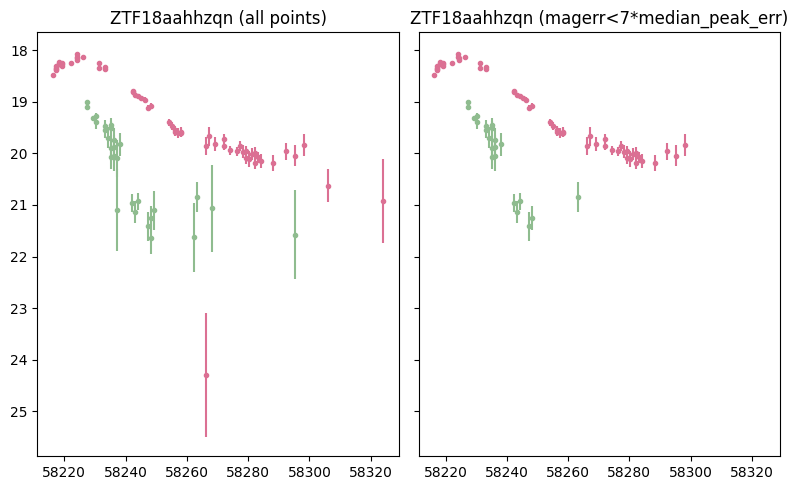

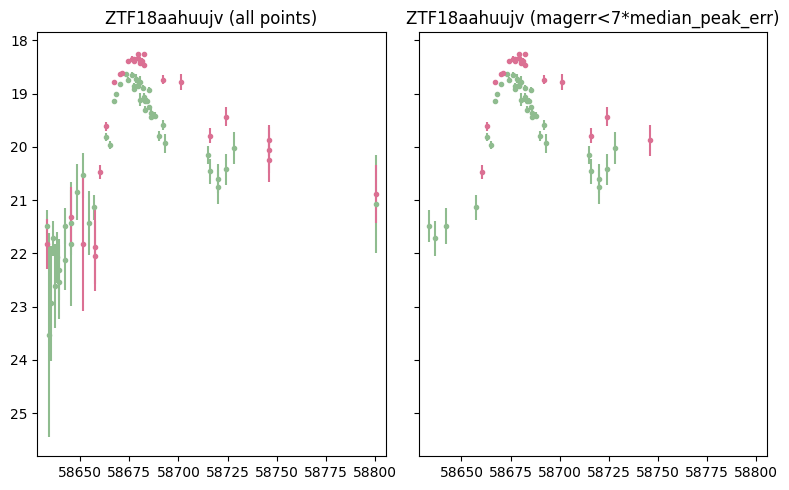

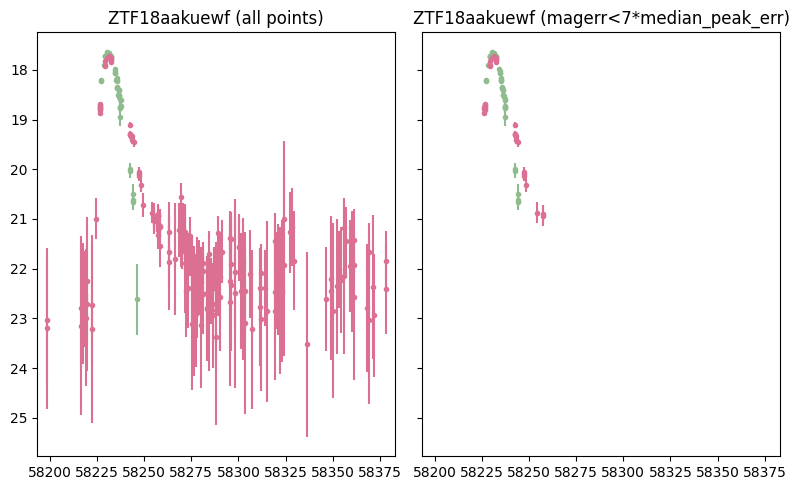

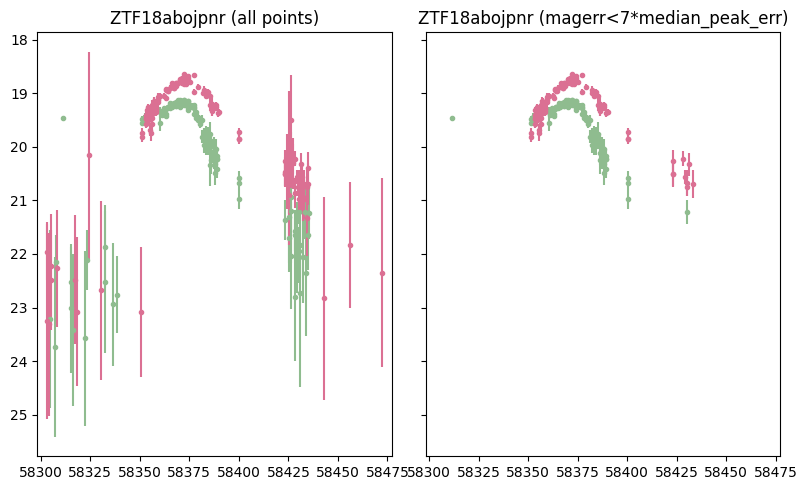

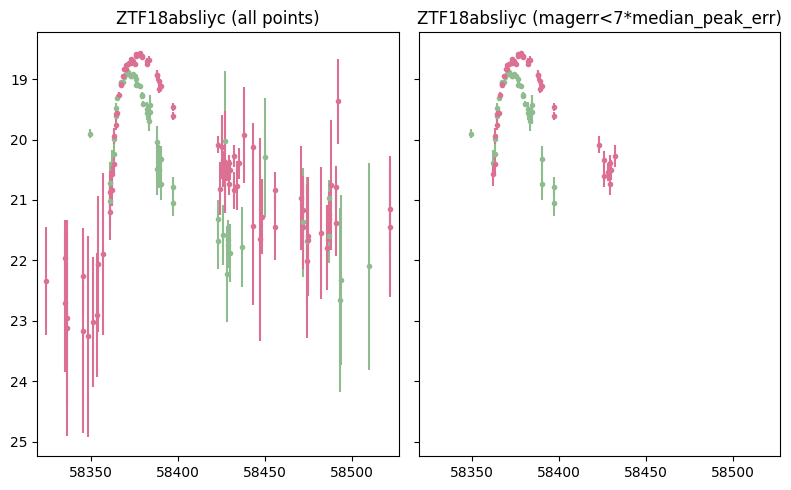

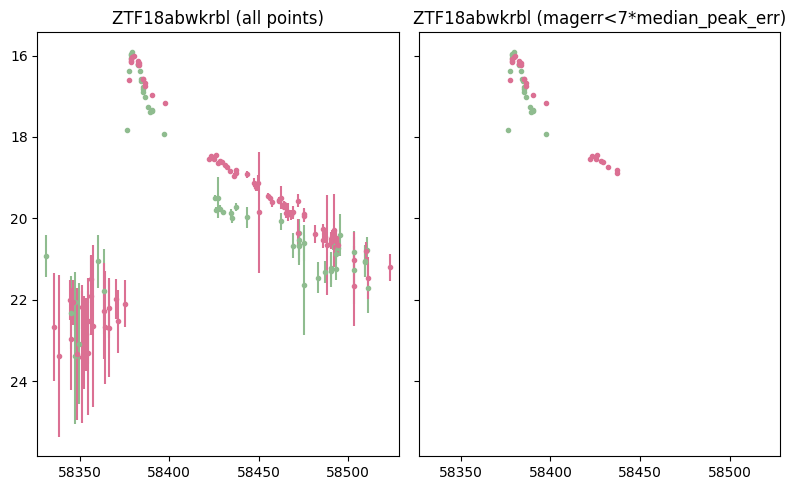

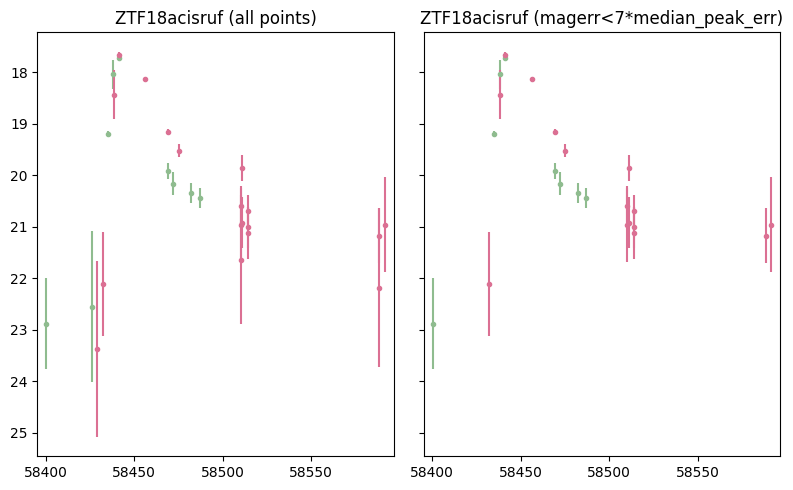

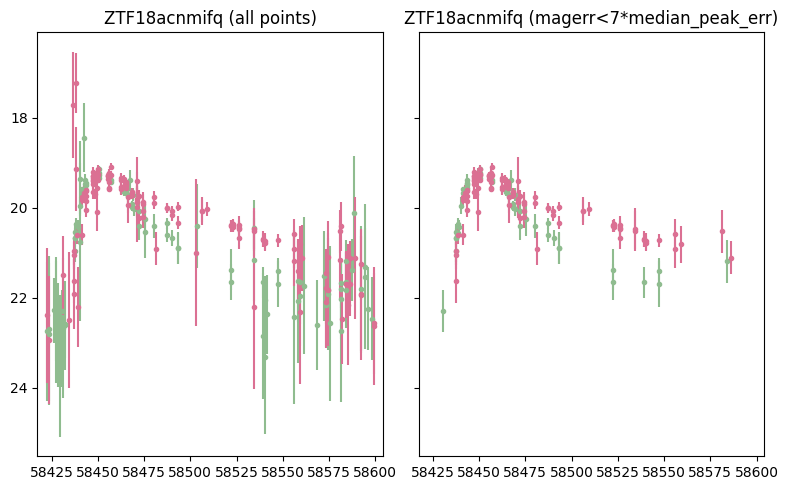

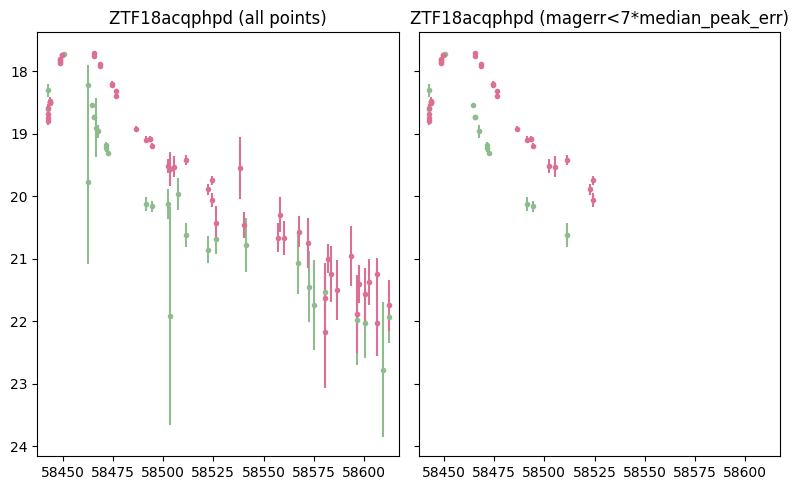

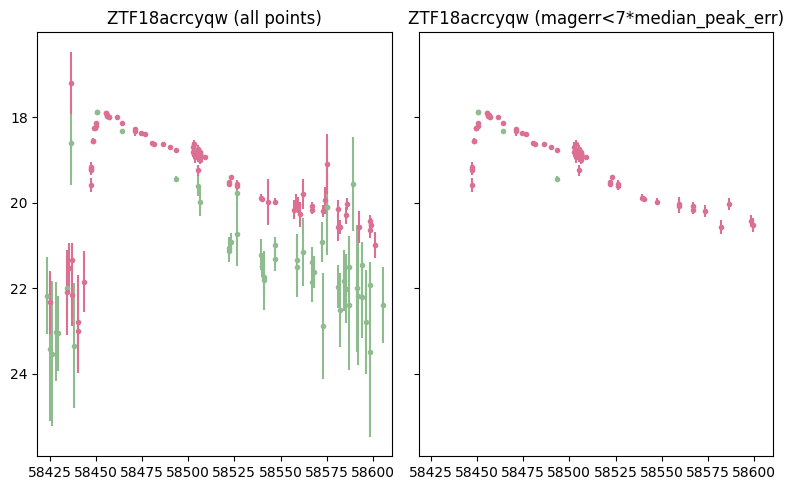

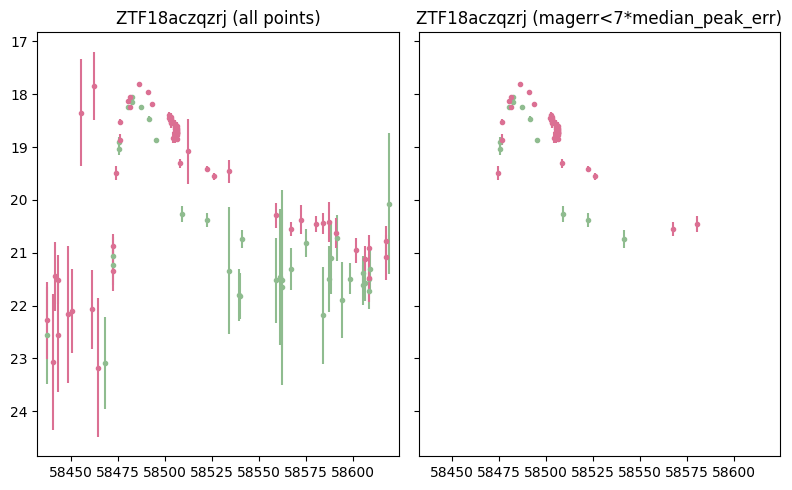

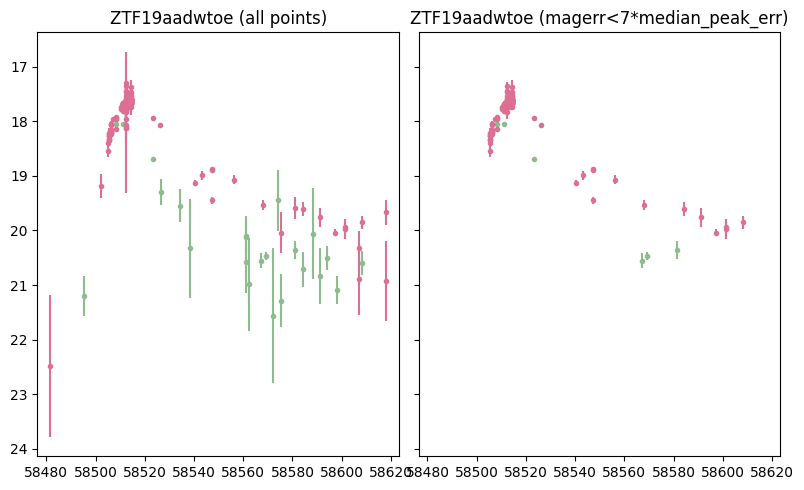

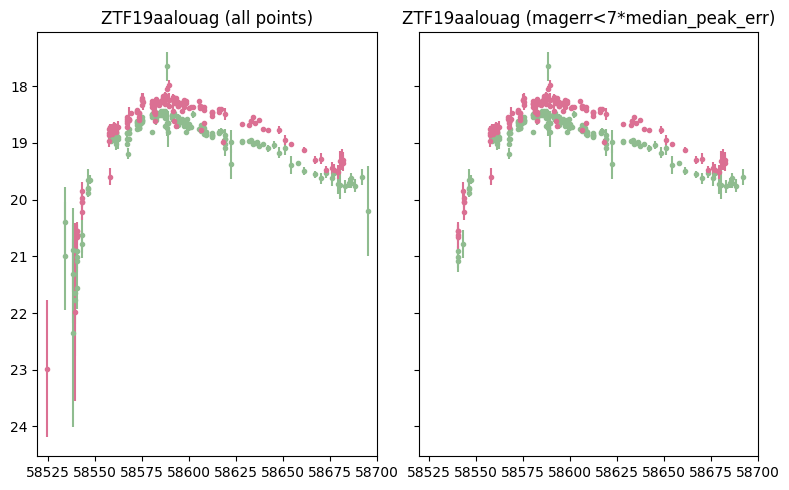

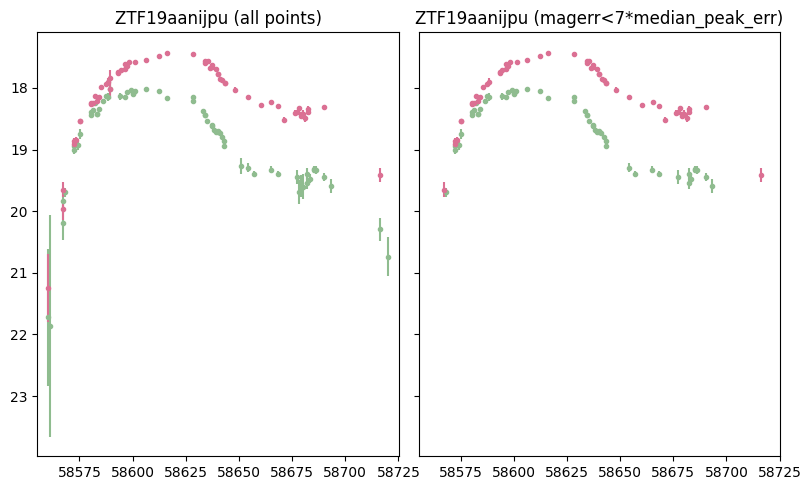

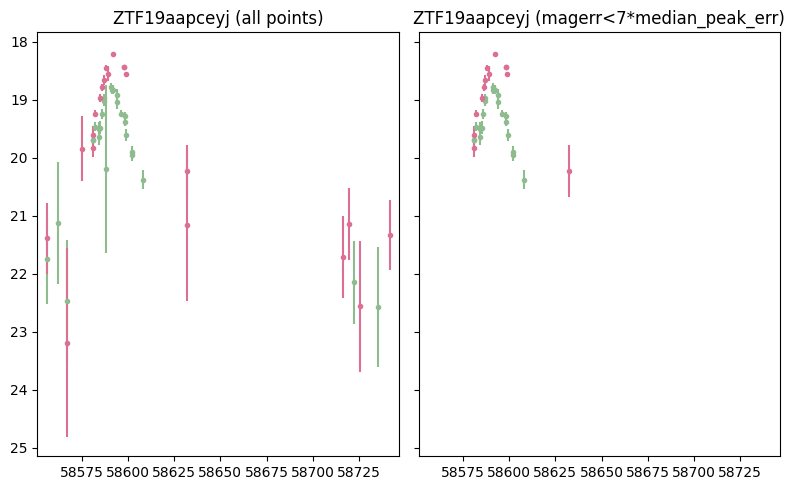

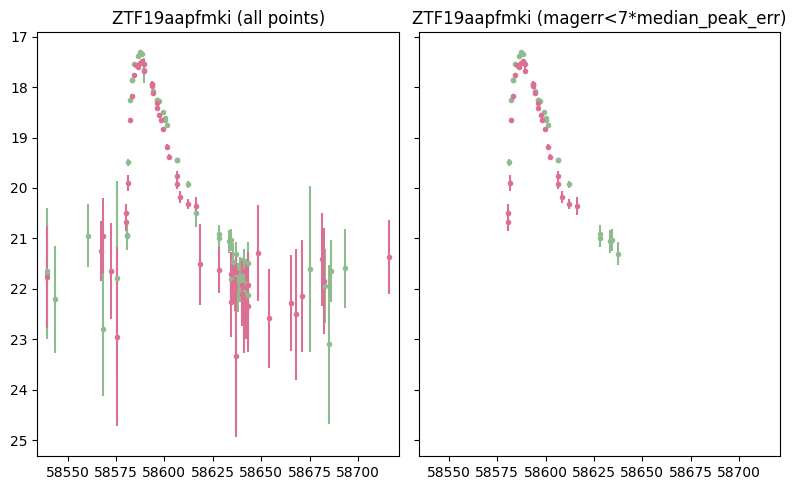

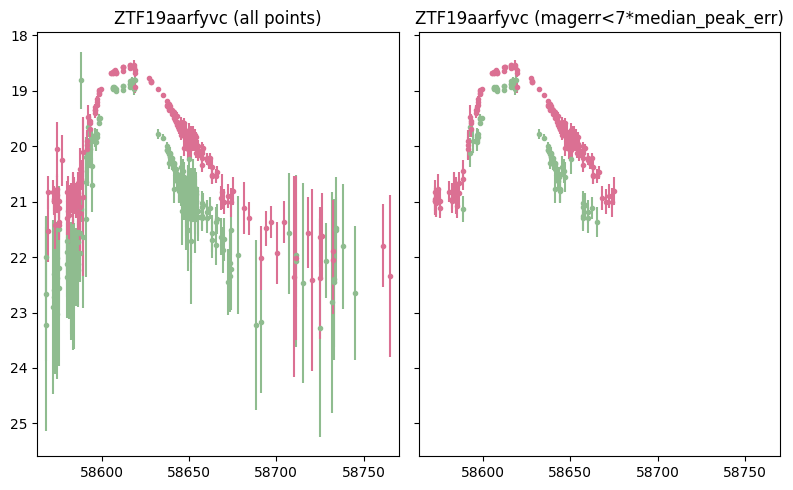

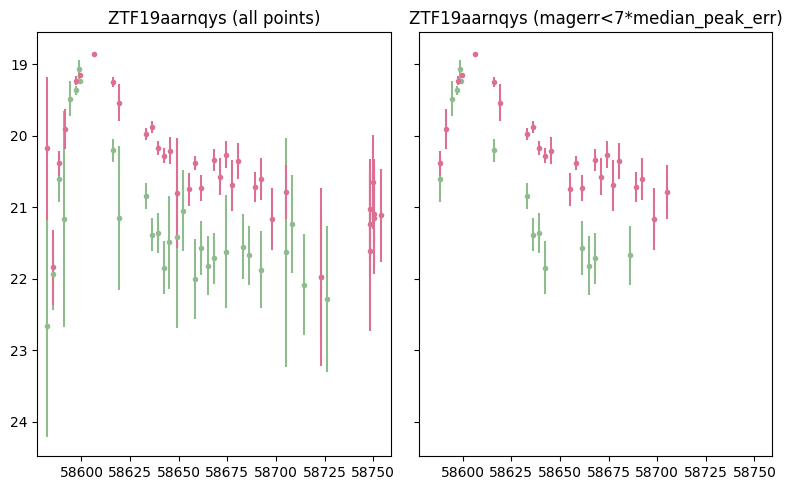

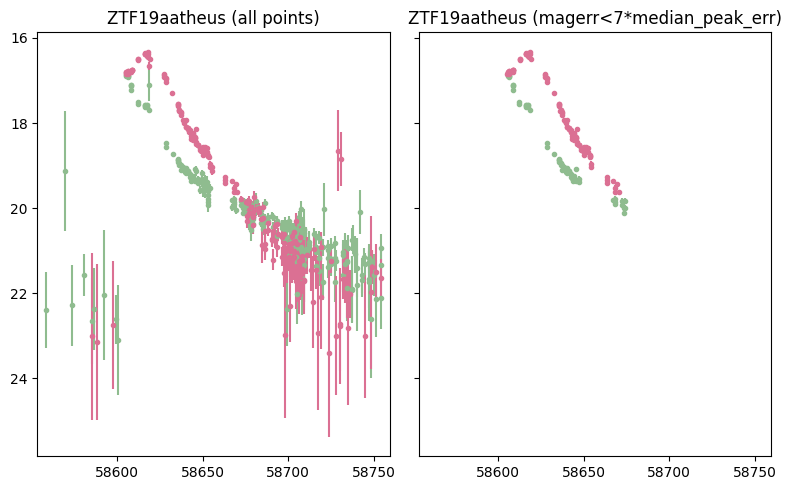

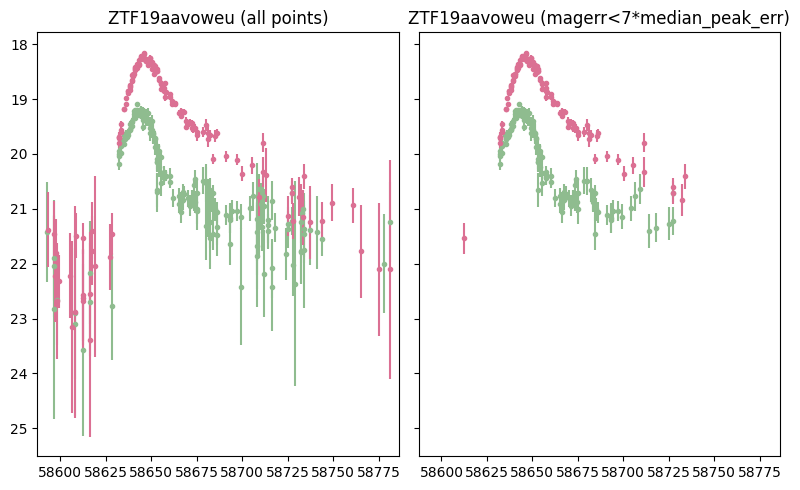

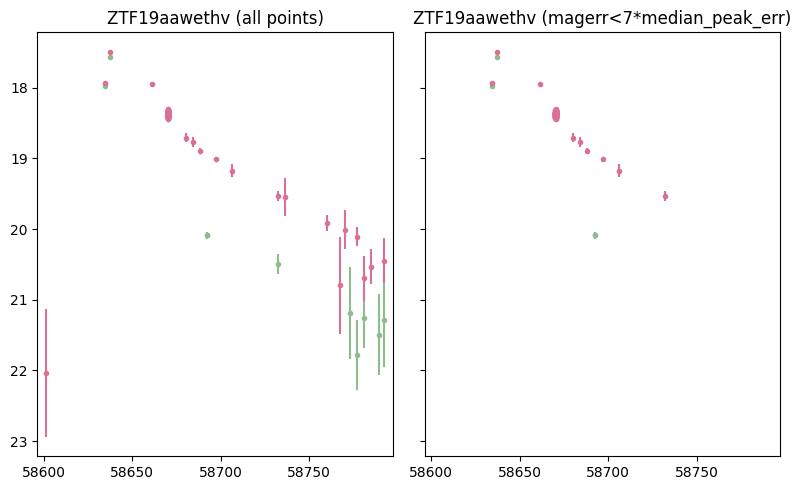

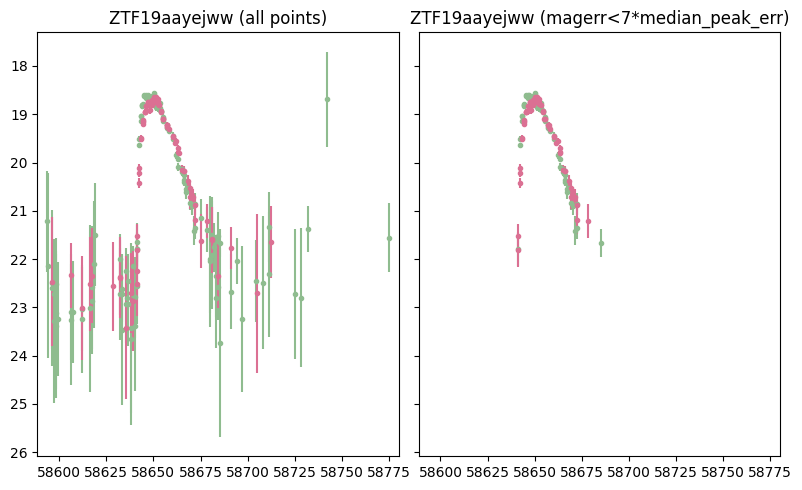

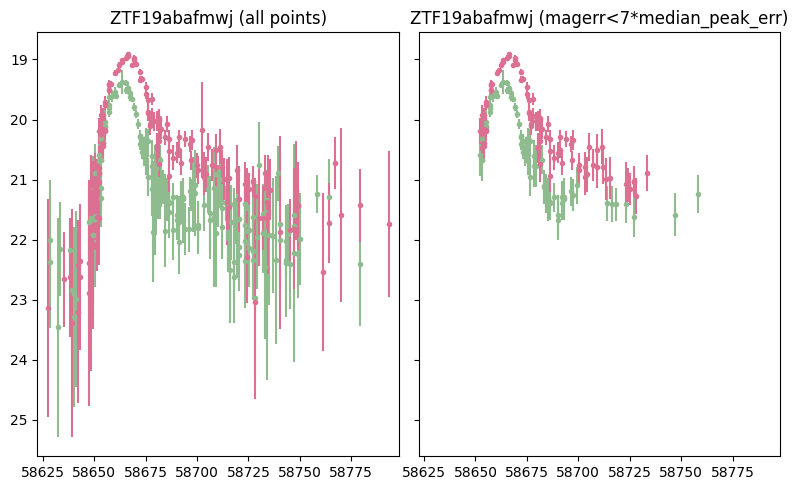

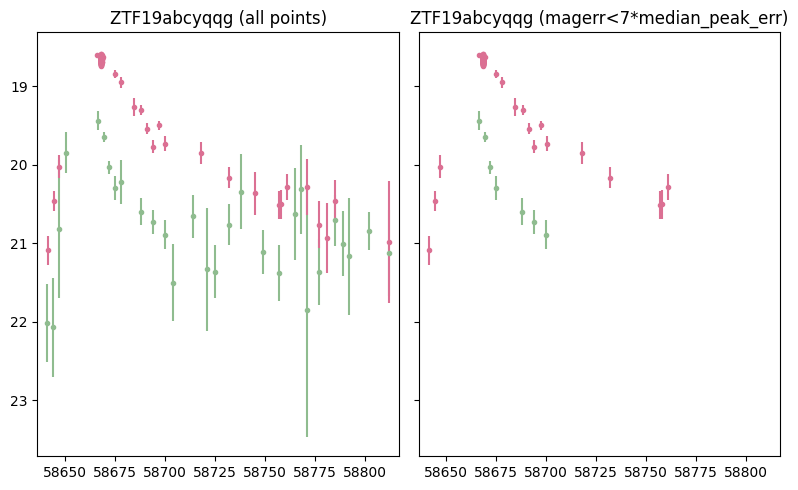

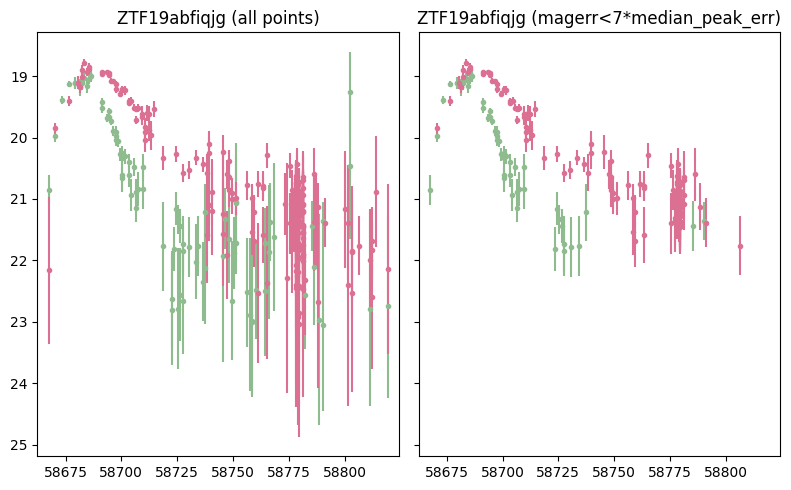

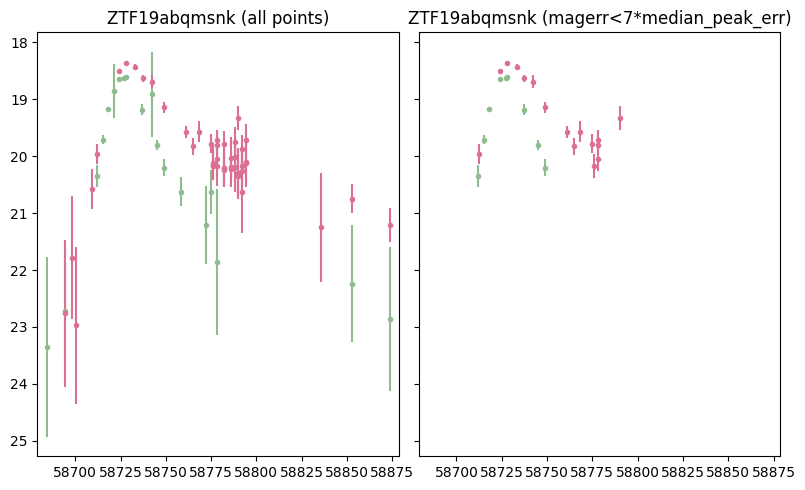

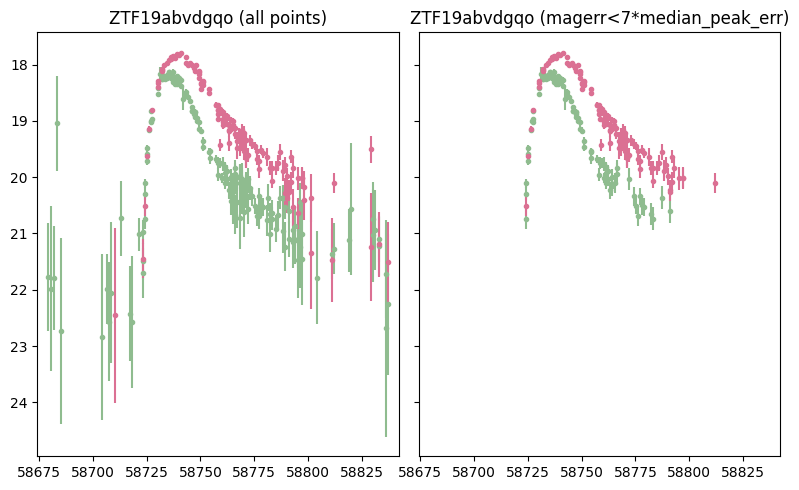

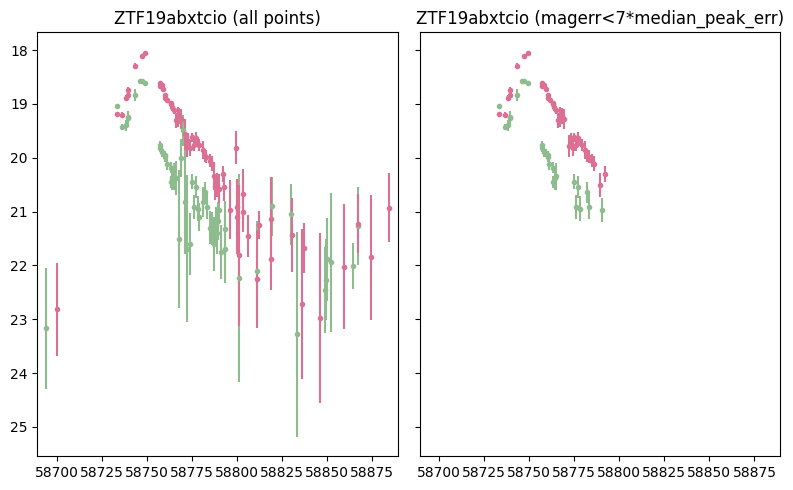

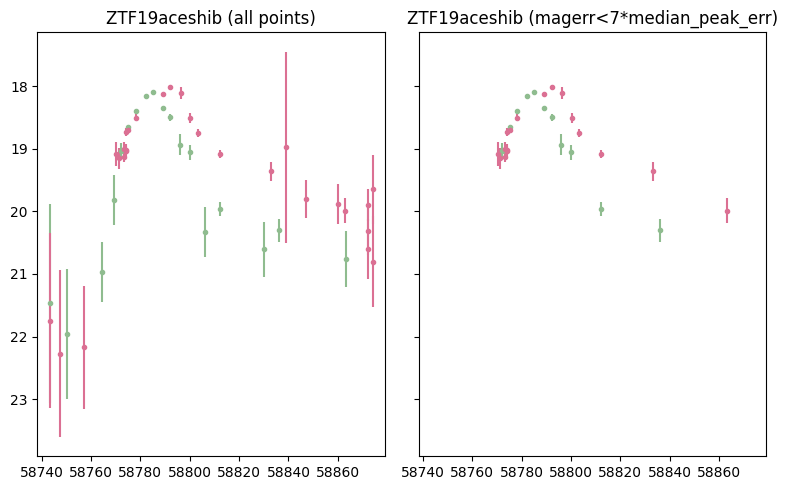

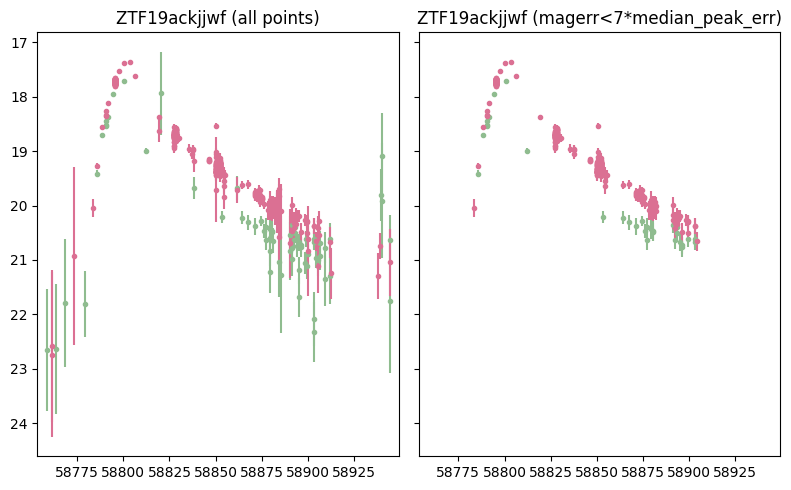

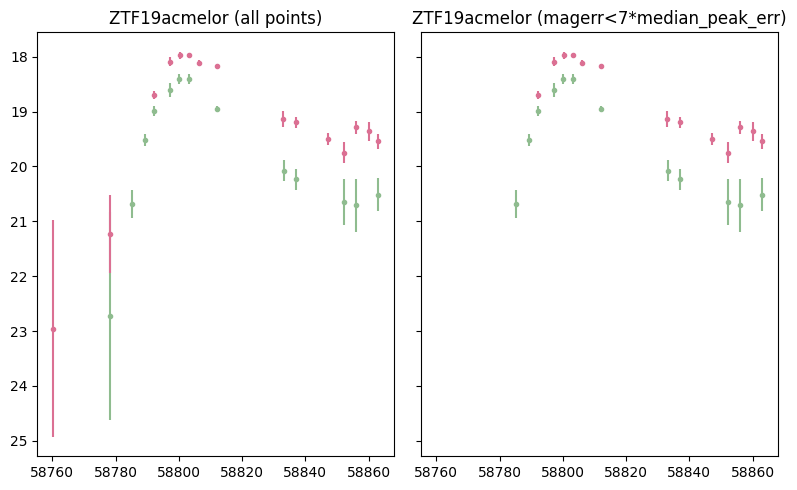

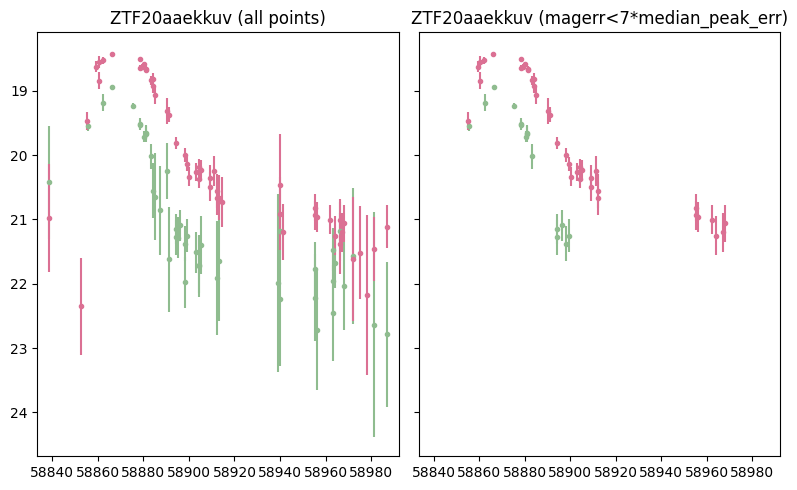

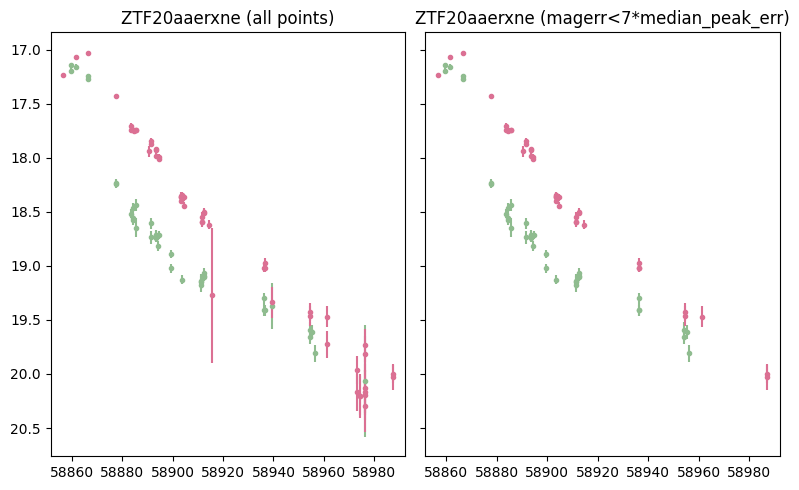

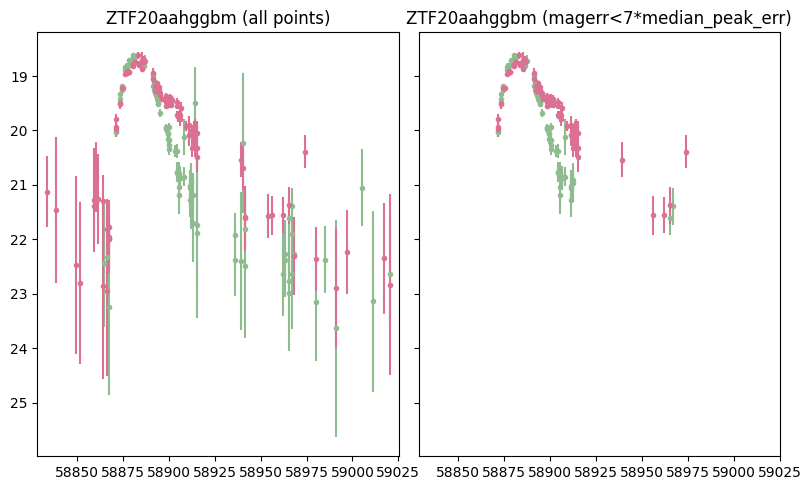

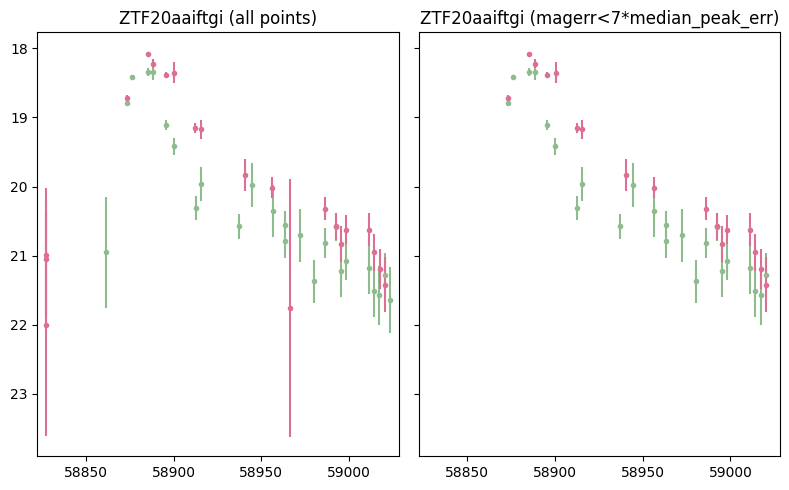

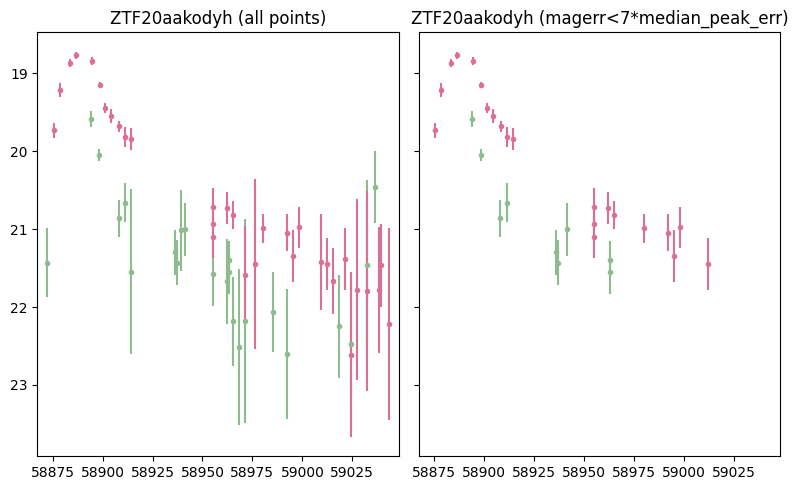

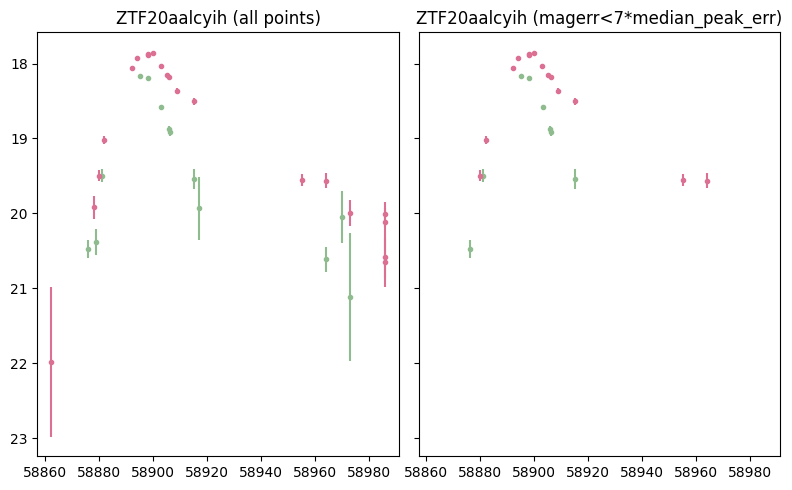

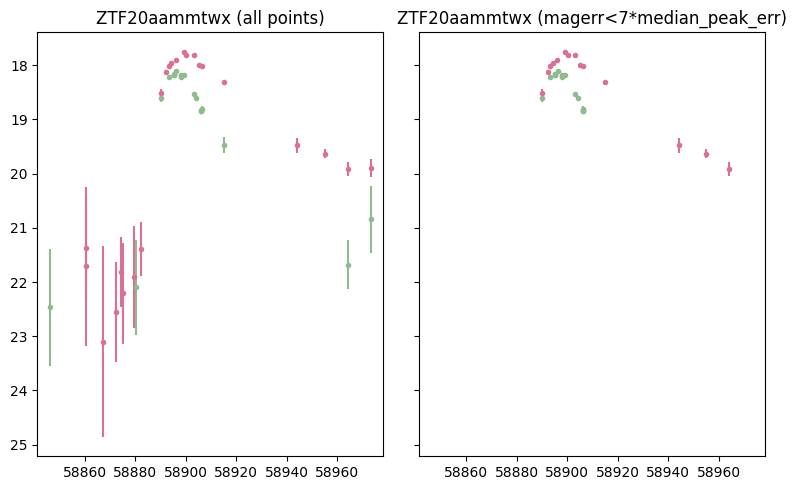

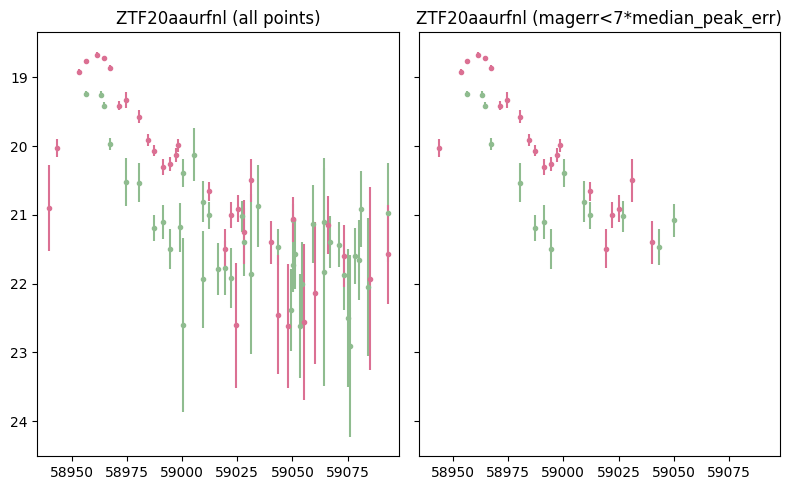

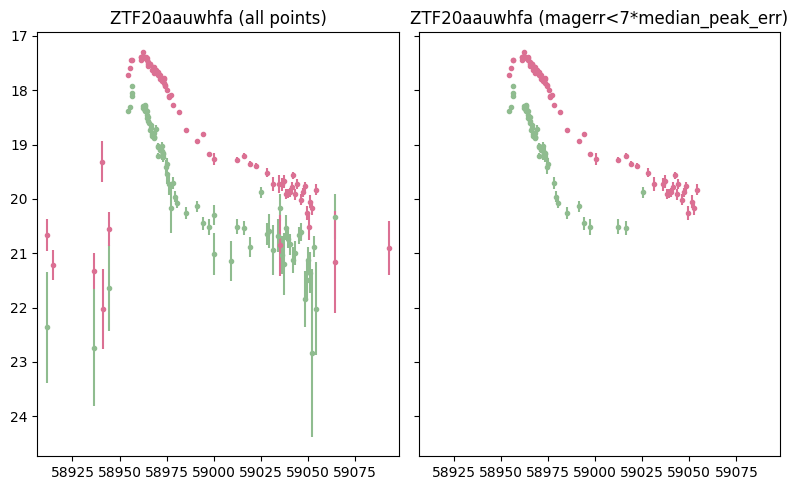

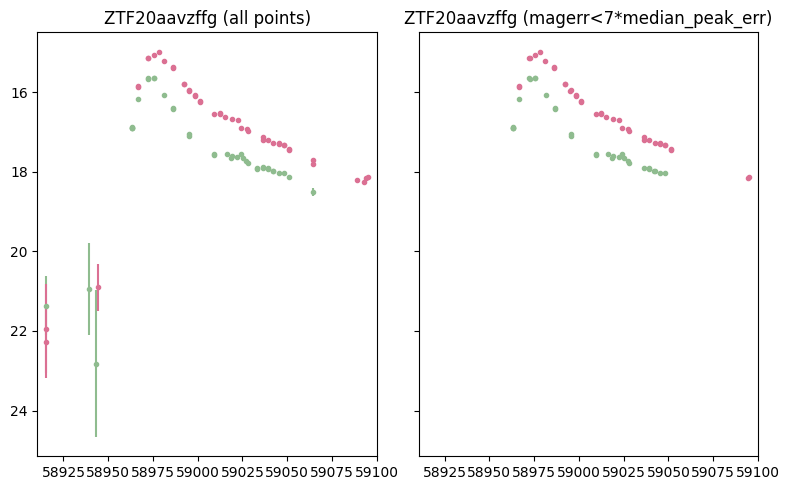

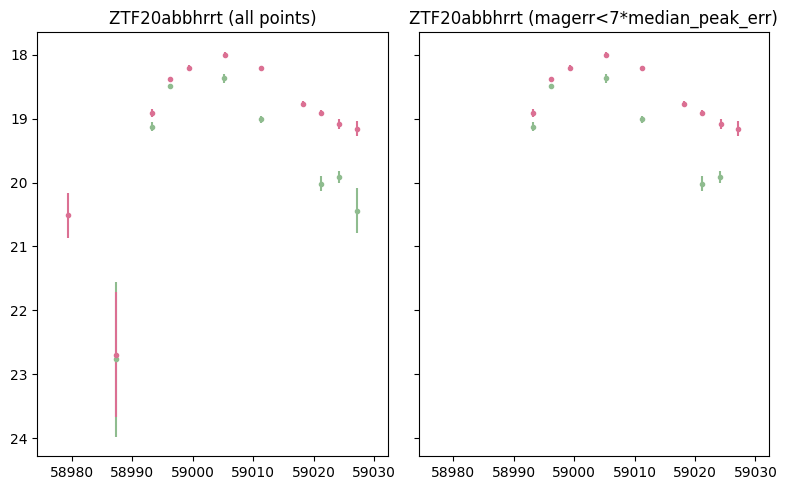

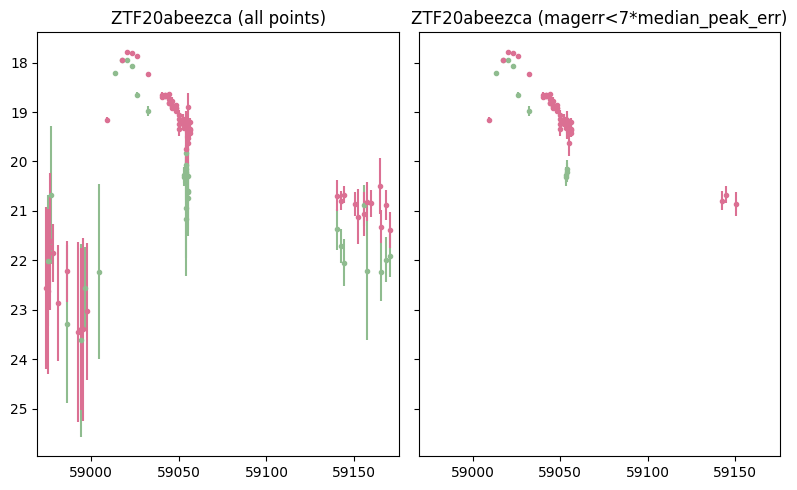

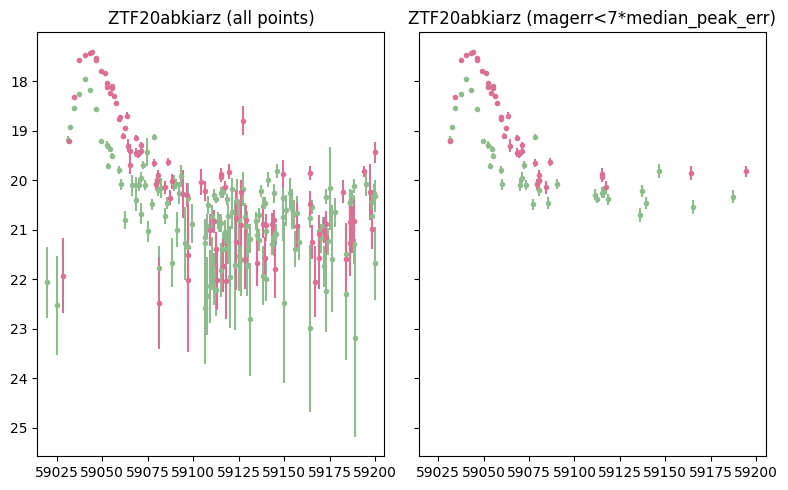

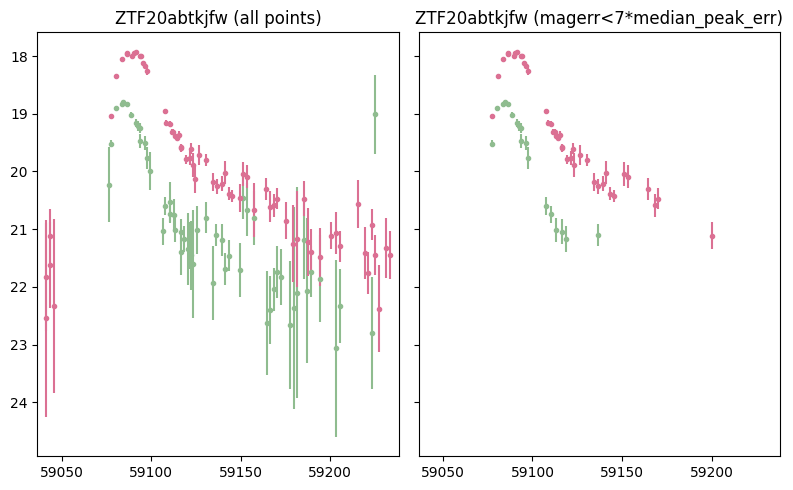

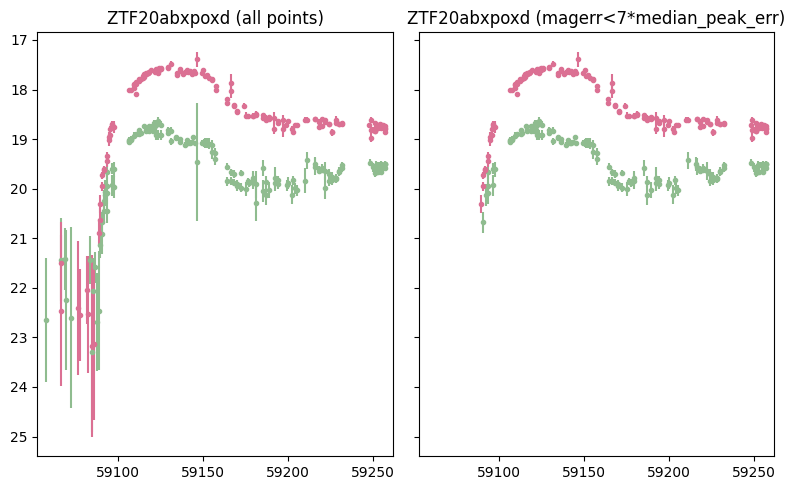

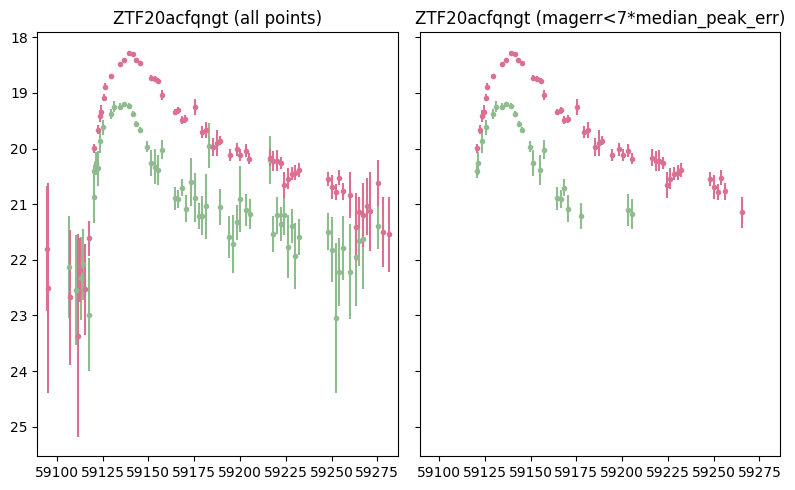

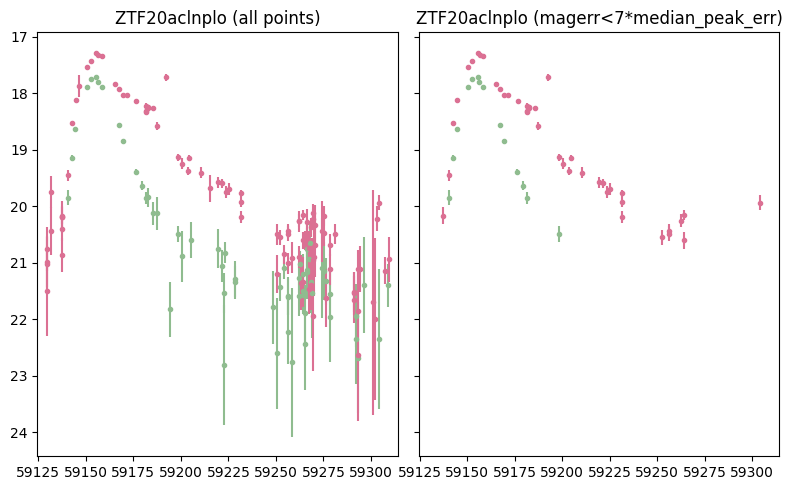

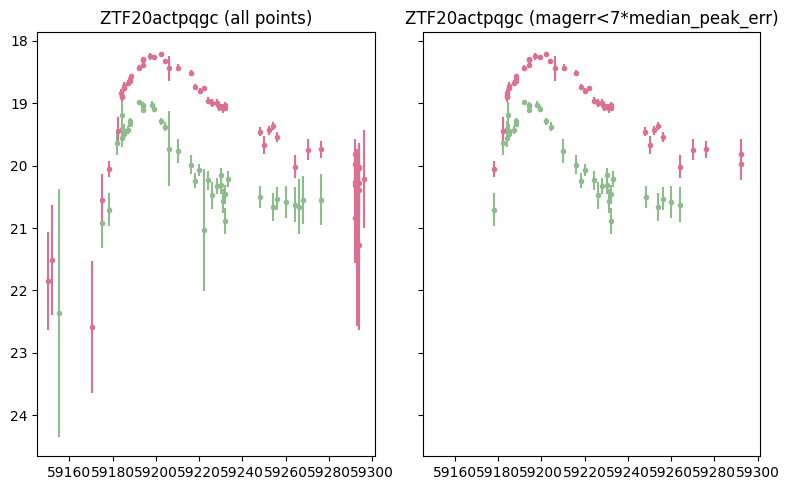

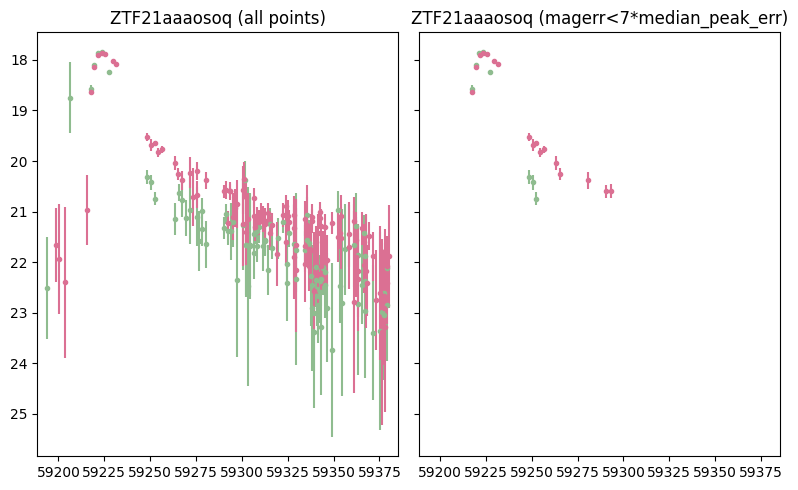

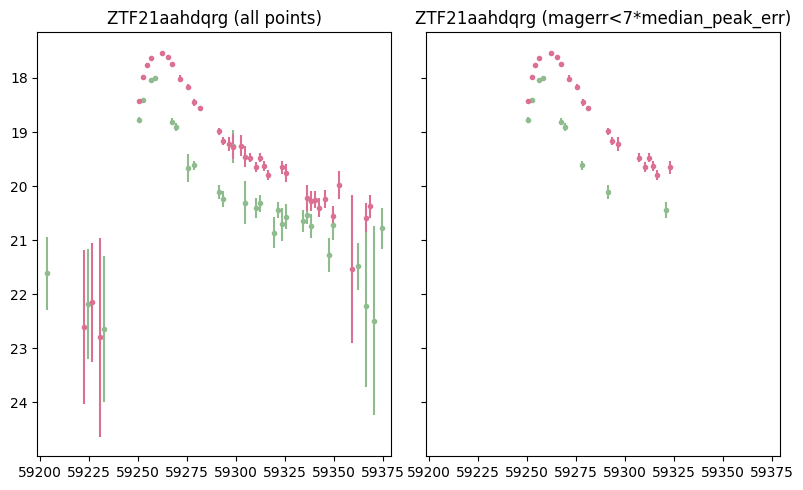

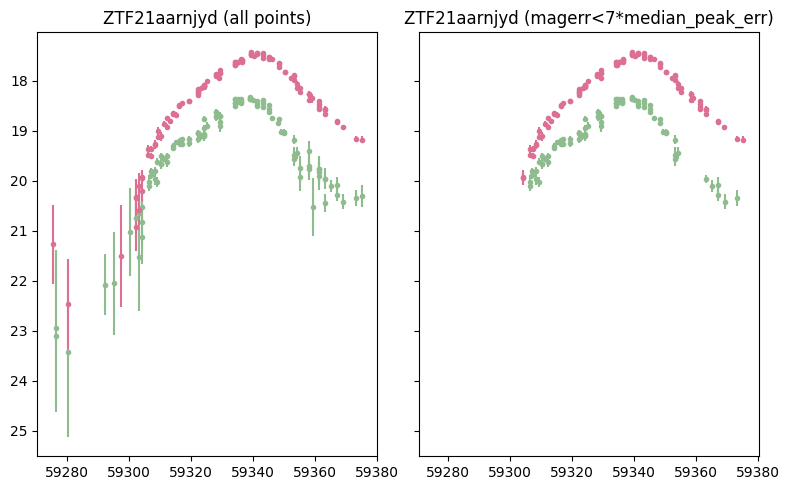

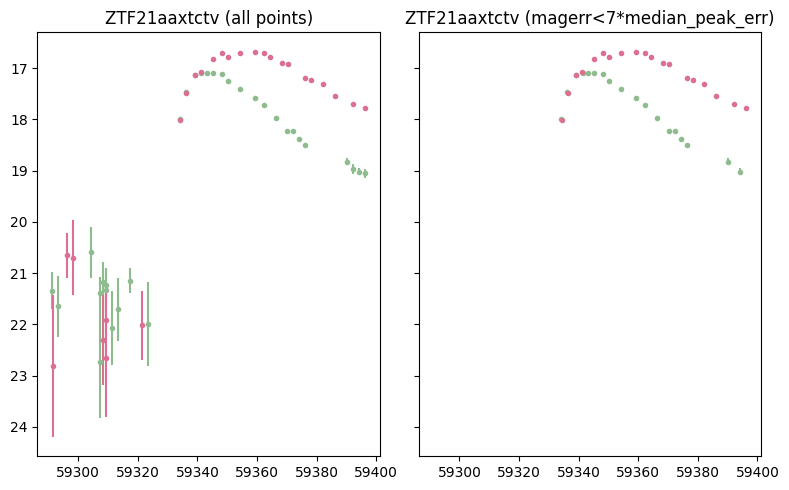

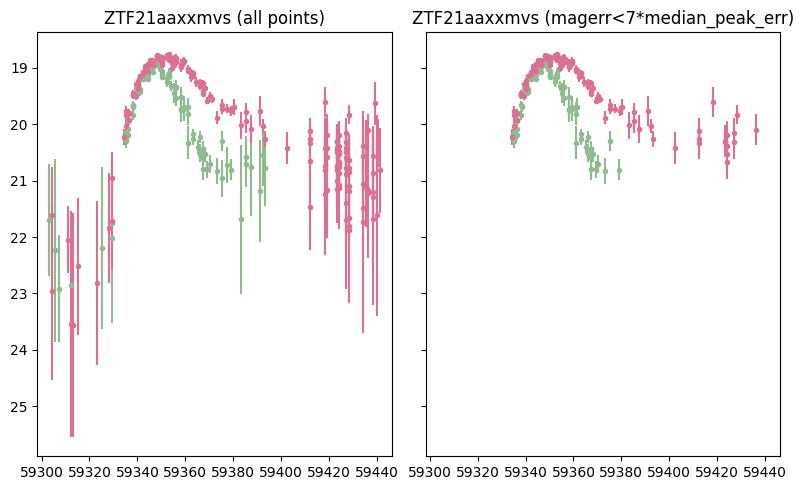

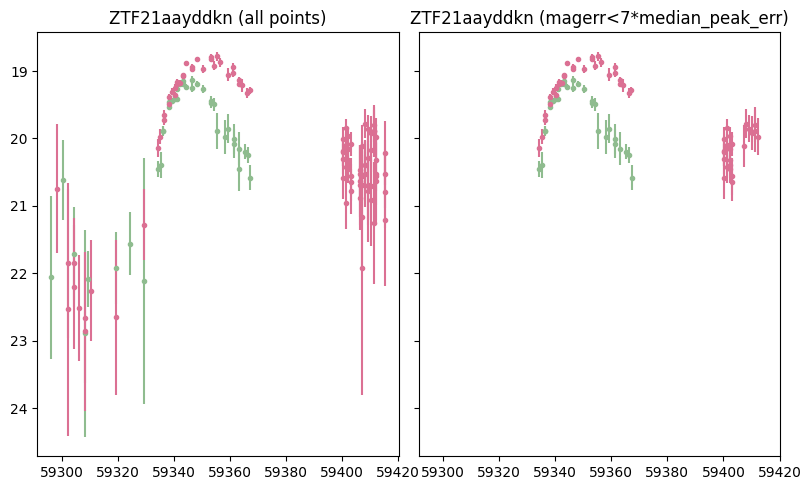

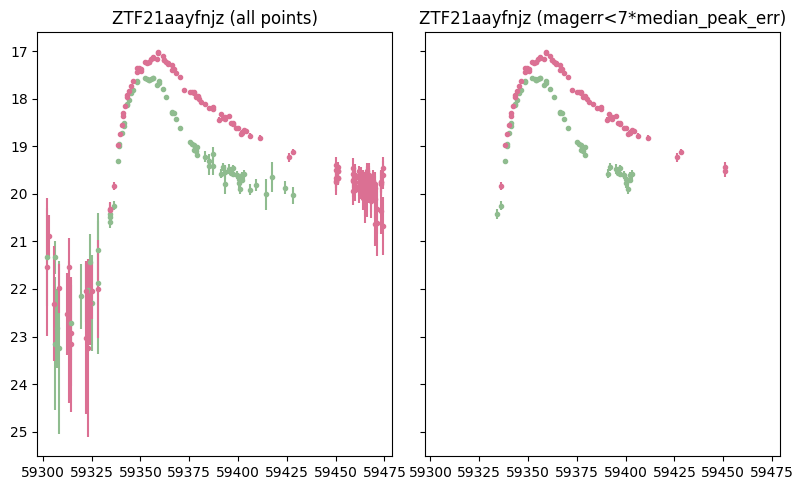

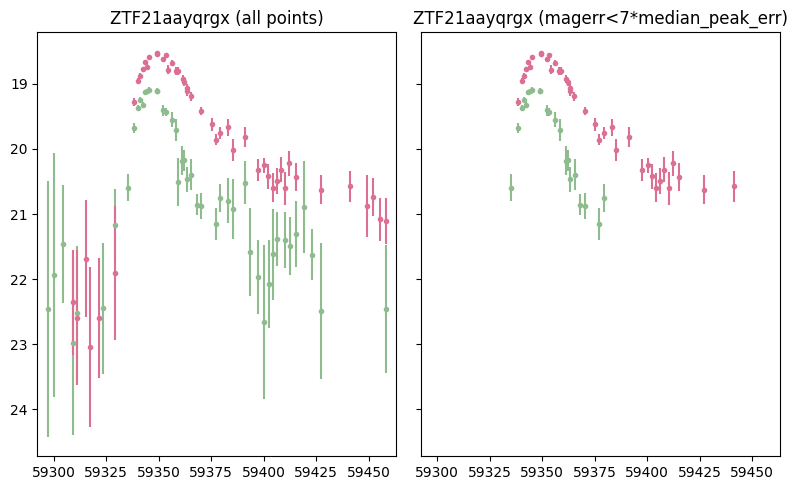

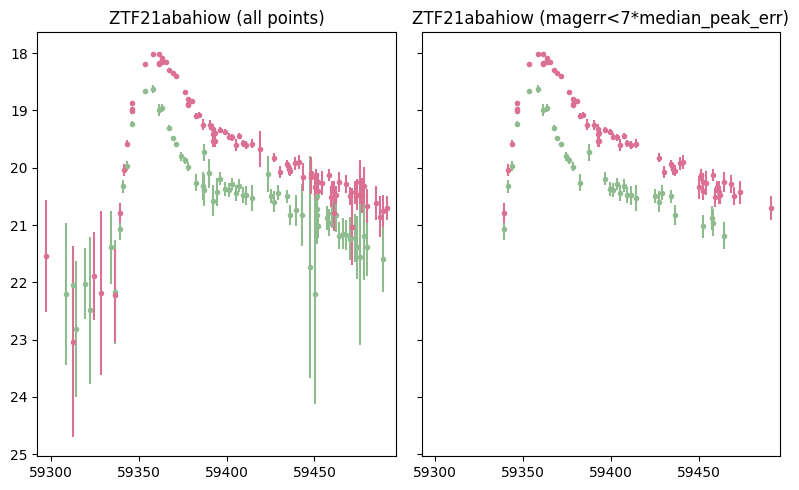

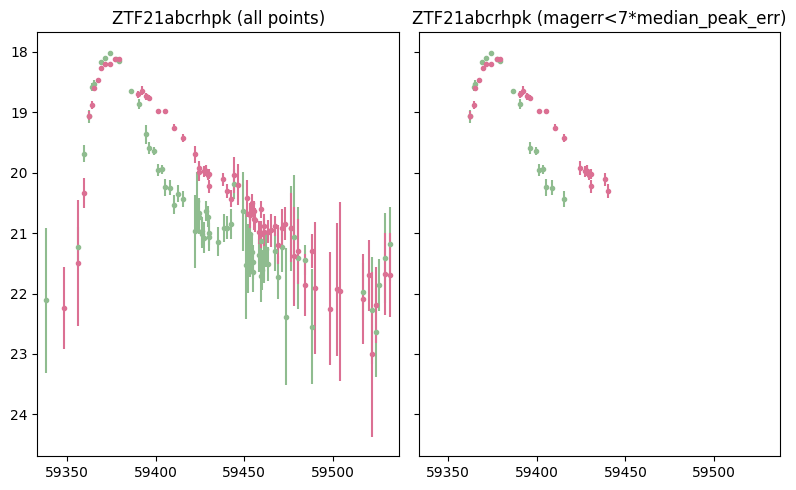

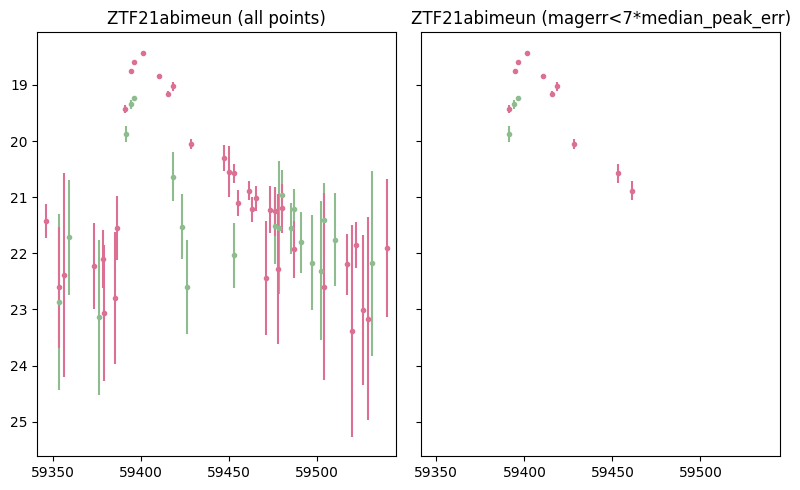

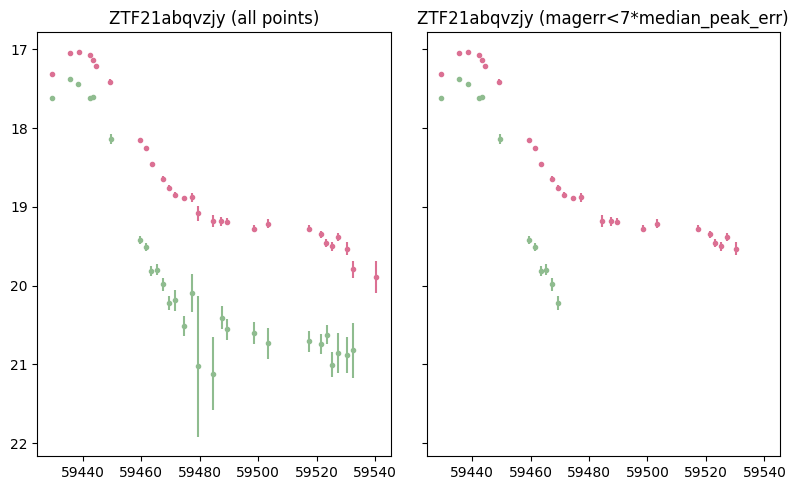

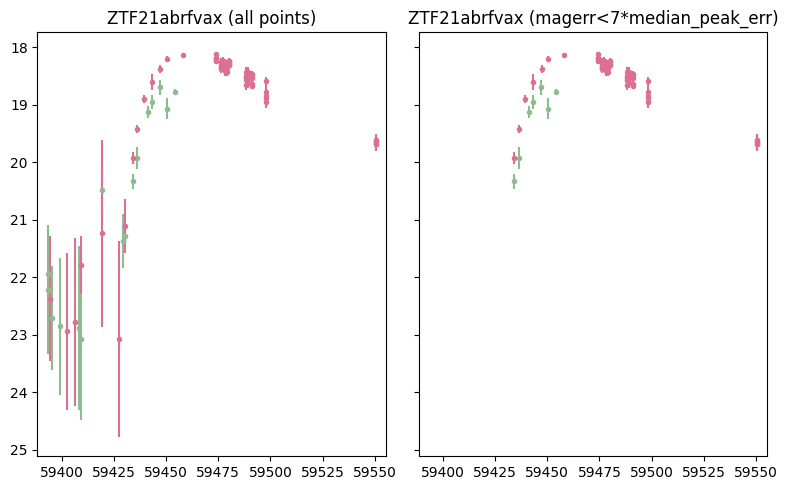

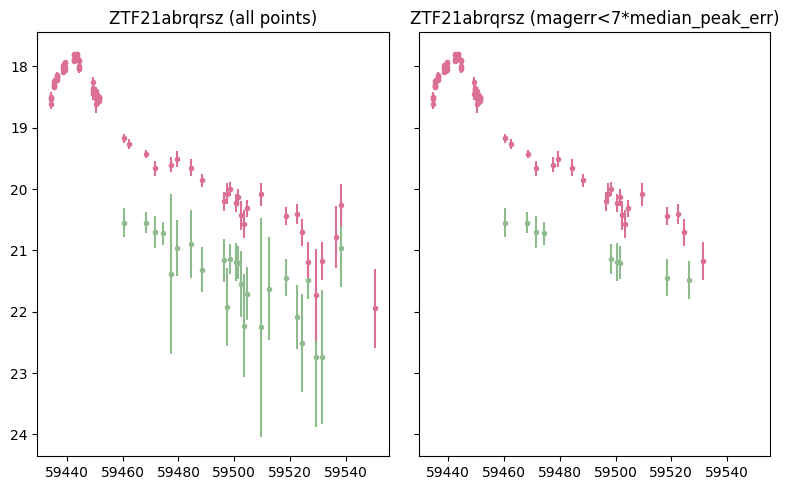

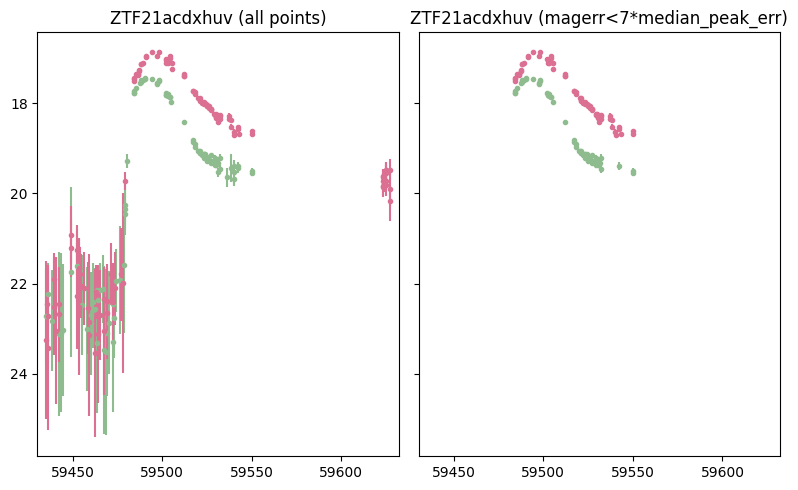

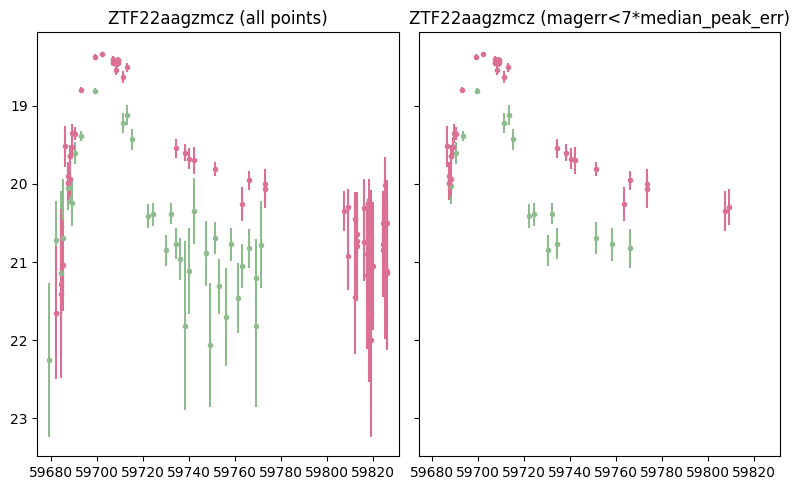

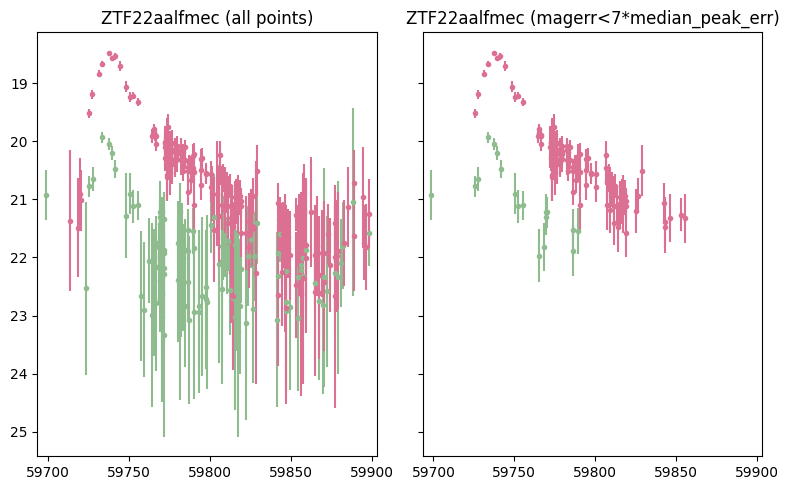

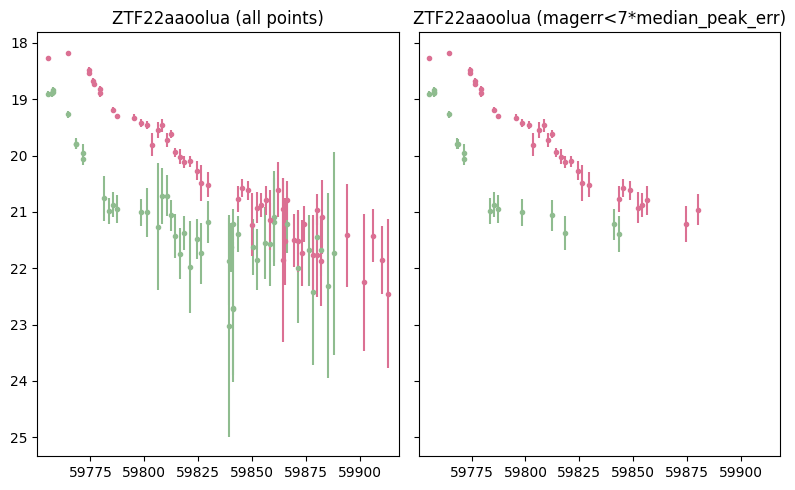

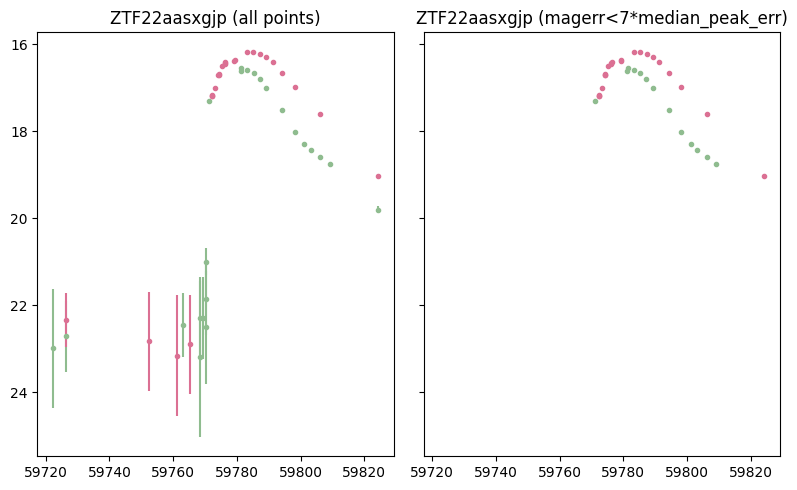

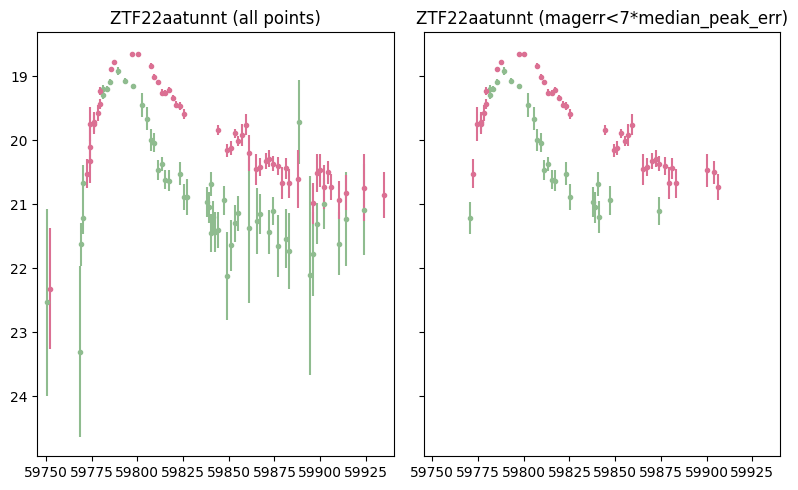

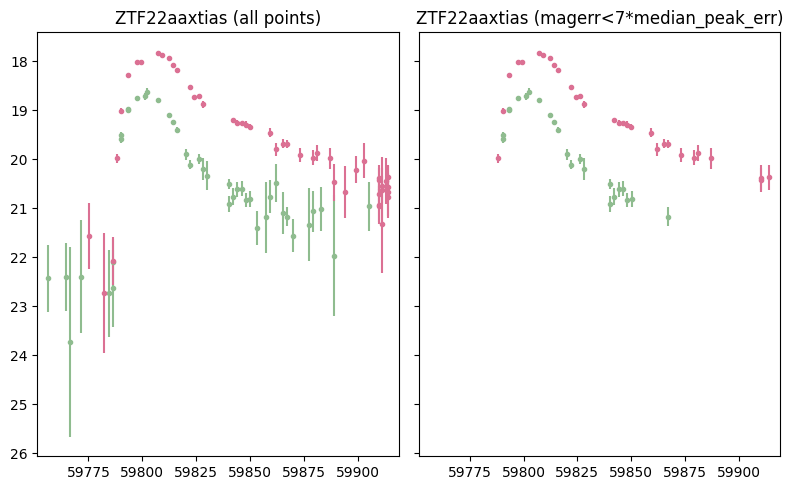

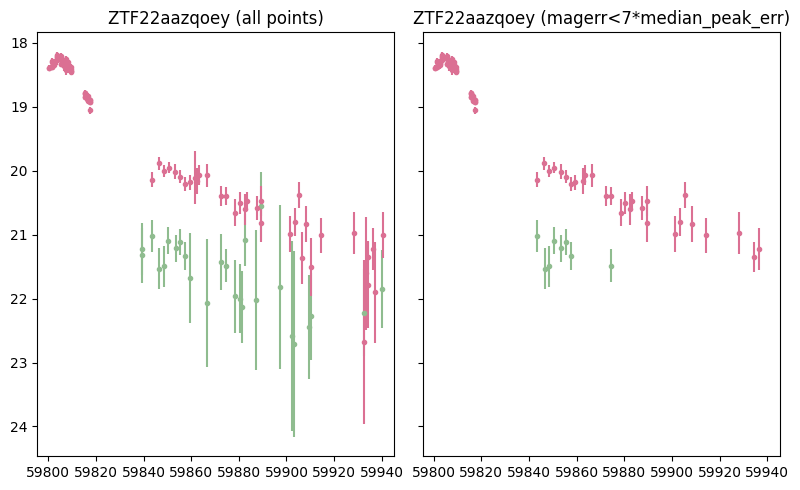

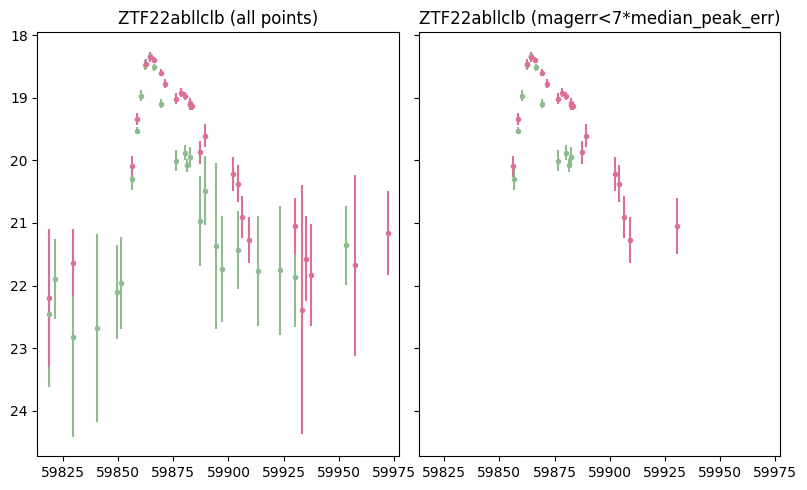

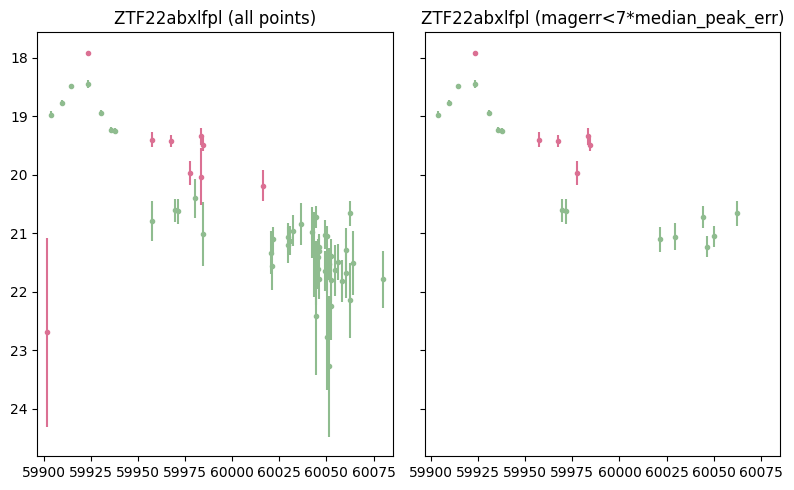

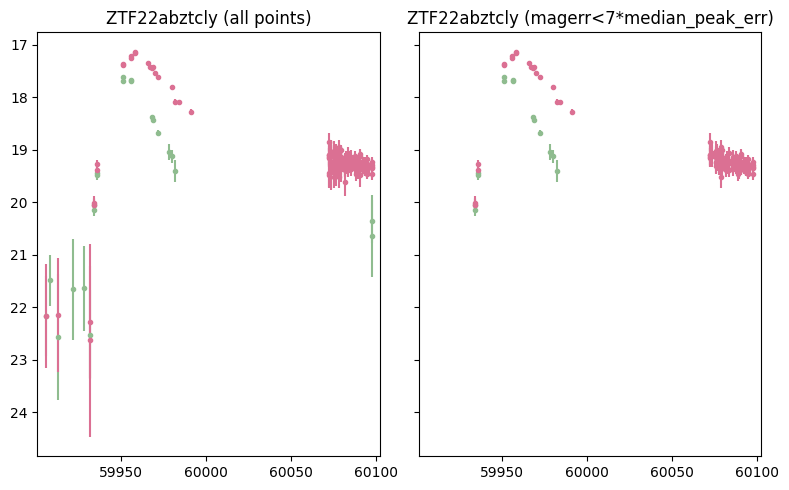

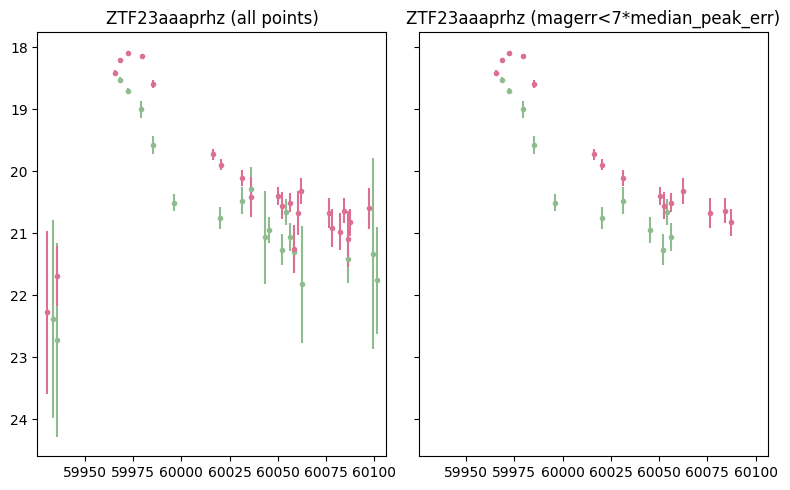

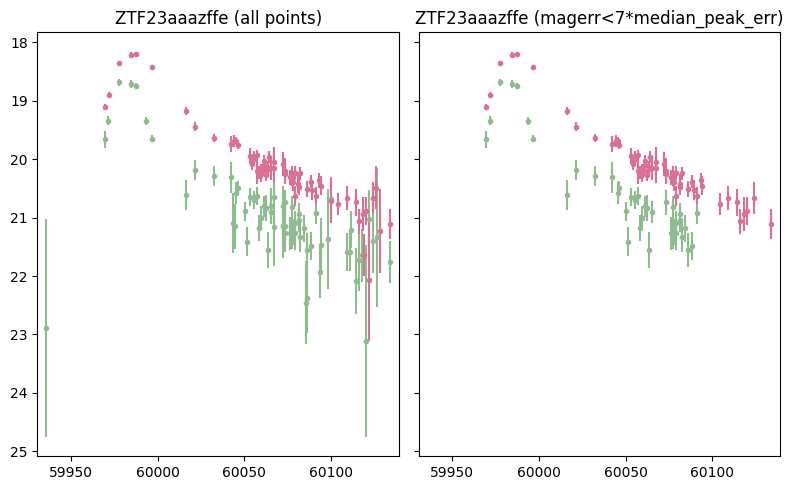

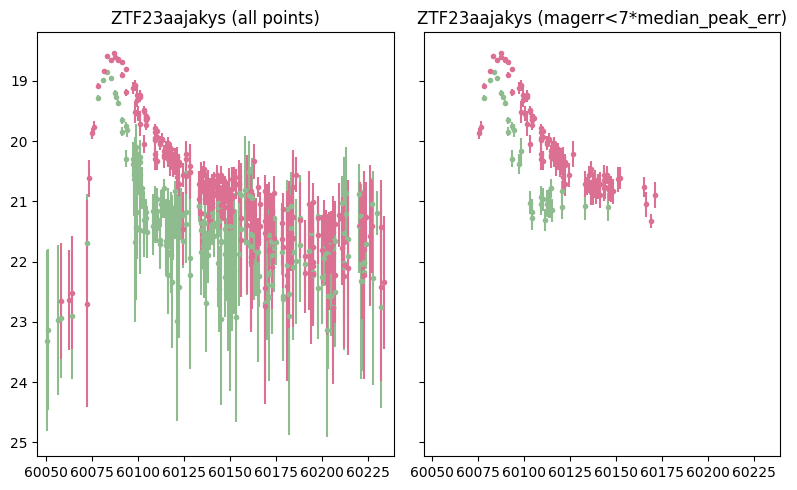

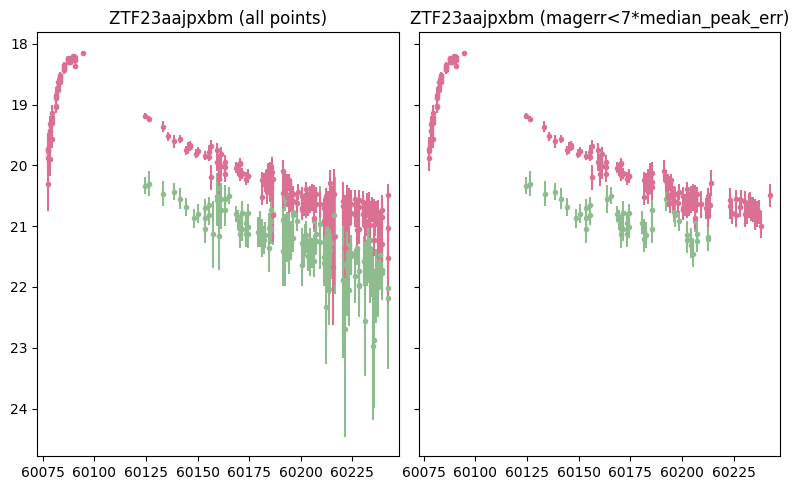

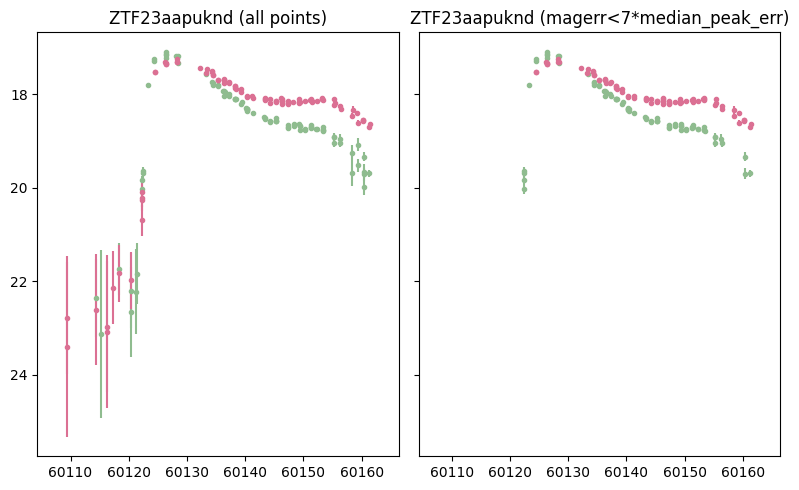

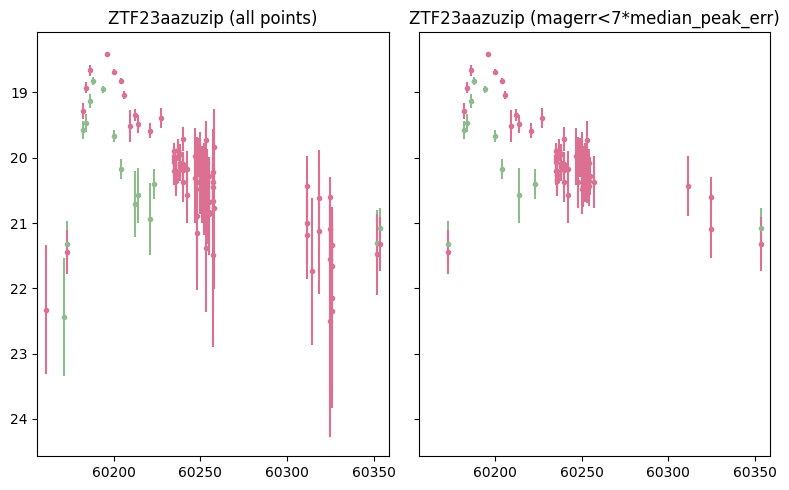

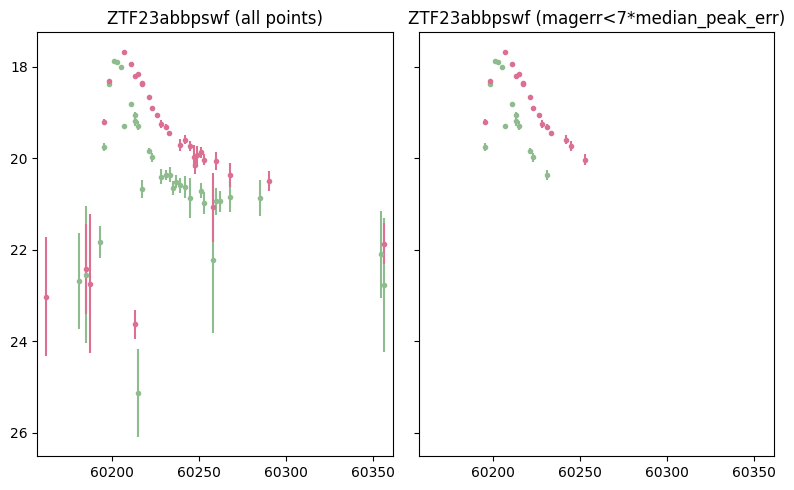

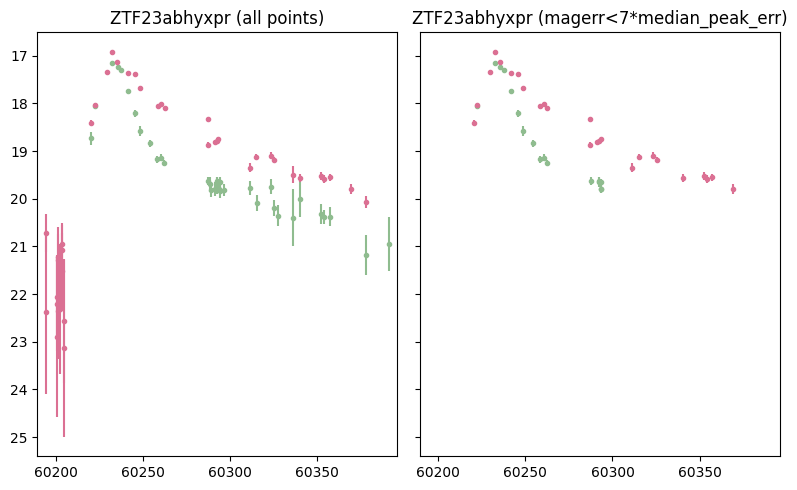

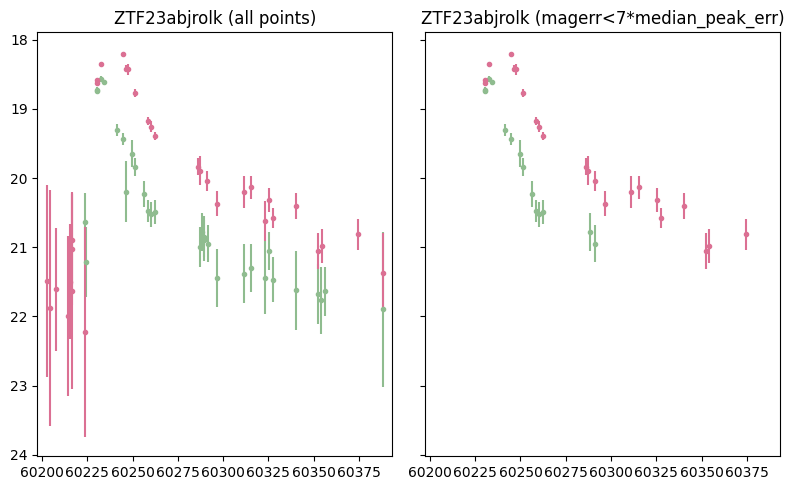

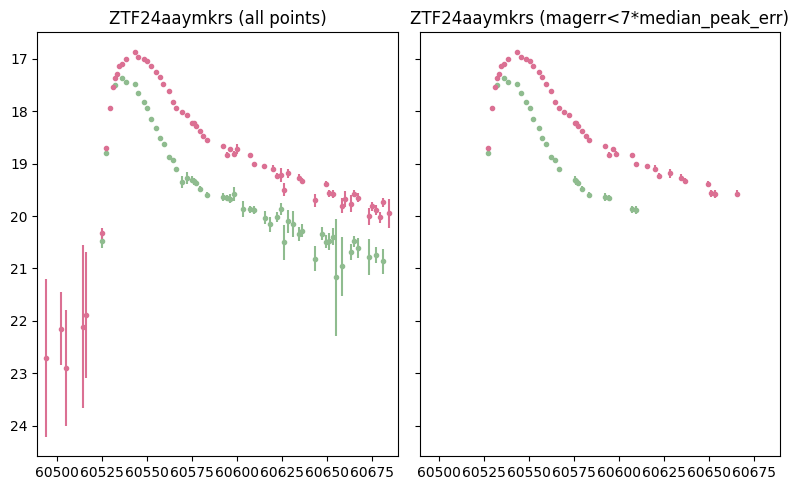

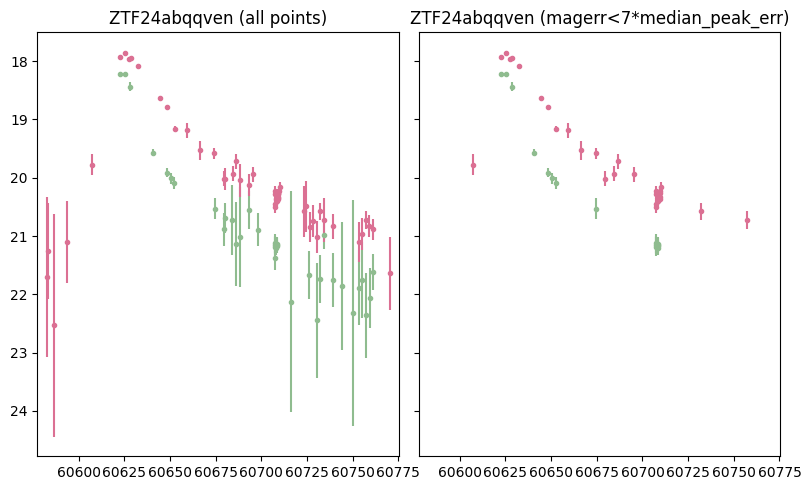

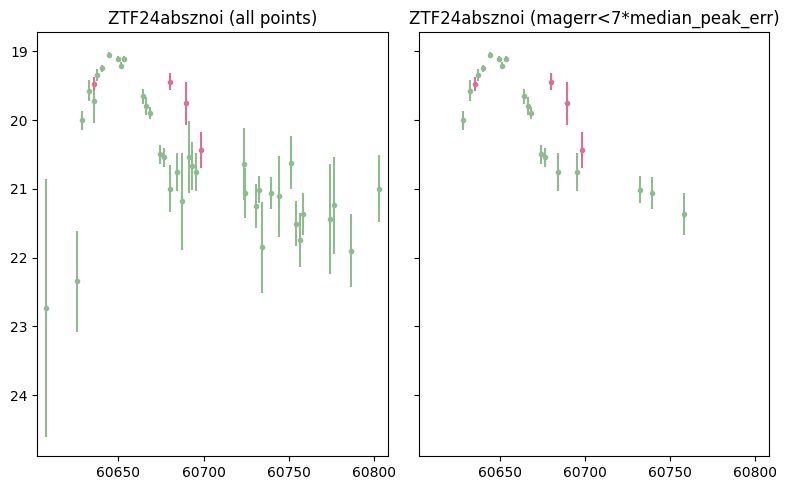

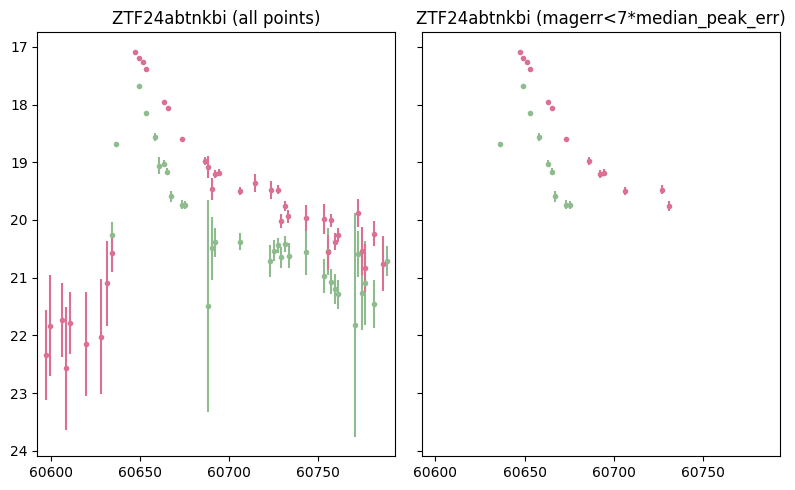

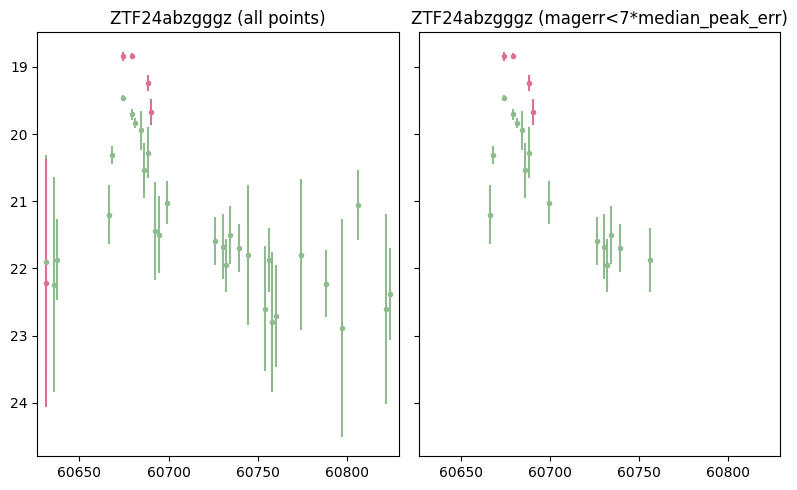

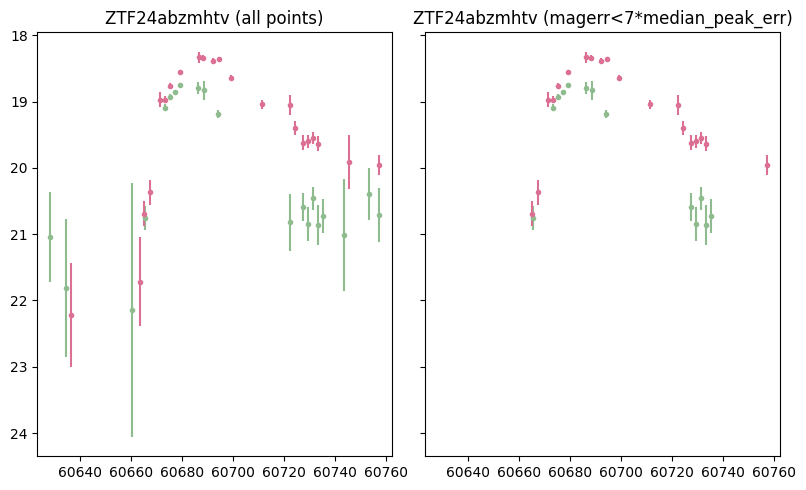

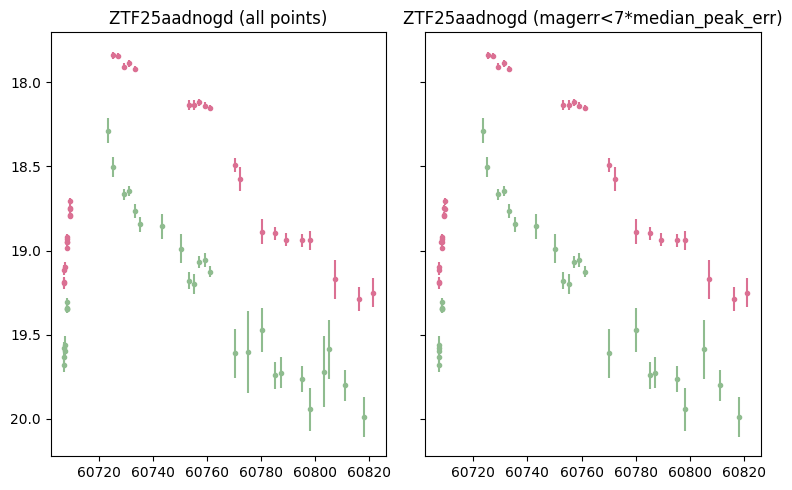

In [111]:
sp_names = info_file.loc[(info_file['synthetic']==False)&(info_file['double-peaked']==False),'ZTFID'].to_list() #selecting only real ztf LCs

for sn in sp_names:
    lc = pd.read_csv(f'data/test/all/light-curves/{sn}_0.csv') #only taking the first copy

    peak_mjd = info_file.loc[info_file['ZTFID']==sn, 'peakt'].iloc[0]
    
    #collecting points -5<= peak mjd [days]<= +10
    peak_pnts = lc.loc[(peak_mjd-5<=lc['time'])&(lc['time']<=peak_mjd+10)]
    median_magerr = peak_pnts['magerr'].median()

    err_factor = 7
    good_err = (lc['magerr']<err_factor*median_magerr)

    fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

    # Left panel: all points
    ax = axes[0]
    ax.errorbar(lc.loc[lc['band']=='g','time'], lc.loc[lc['band']=='g','mag'], lc.loc[lc['band']=='g','magerr'],
                marker='.', ls='', color='darkseagreen')
    ax.errorbar(lc.loc[lc['band']=='R','time'], lc.loc[lc['band']=='R','mag'], lc.loc[lc['band']=='R','magerr'],
                marker='.', ls='', color='palevioletred')
    ax.set_xlim(min(lc['time']-5), max(lc['time']+5))
    ax.set_title(f'{sn} (all points)')

    # Right panel: only good-error points
    ax = axes[1]
    ax.errorbar(lc.loc[(lc['band']=='g')&good_err,'time'], lc.loc[(lc['band']=='g')&good_err,'mag'], lc.loc[(lc['band']=='g')&good_err,'magerr'],
                marker='.', ls='', color='darkseagreen')
    ax.errorbar(lc.loc[(lc['band']=='R')&good_err,'time'], lc.loc[(lc['band']=='R')&good_err,'mag'], lc.loc[(lc['band']=='R')&good_err,'magerr'],
                marker='.', ls='', color='palevioletred')
    ax.set_xlim(min(lc['time']-5), max(lc['time']+5))
    ax.set_title(f'{sn} (magerr<{err_factor}*median_peak_err)')

    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'figures/ztf_lc_cutoffs/{sn}_cutoff_{err_factor}.png')

    plt.show()